In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("ressources")

df_reservations = pd.read_csv(DATA_DIR / "reservations_train.csv")
df_reservations_test = pd.read_csv(DATA_DIR / "reservations_test.csv")
# test_df = pd.read_csv(DATA_DIR / "reservations_test.csv")
# data_dict = pd.read_csv(DATA_DIR / "data_dictionary.csv")

print("Train :", df_reservations.shape)
# print("Test  :", test_df.shape)

Train : (8000, 34)


### Étape 1: EDA et Préparation

#### Analyse de la Variable Cible: `reservation_annulee`

La variable cible pour cette analyse est `reservation_annulee`, qui indique si une réservation a été annulée (1) ou non (0).

In [4]:
# Vérifier le type de données de la variable cible
display(df_reservations['reservation_annulee'].dtype)

# Vérifier les valeurs manquantes dans la variable cible
display(df_reservations['reservation_annulee'].isnull().sum())

# Afficher la distribution de la variable cible
display(df_reservations['reservation_annulee'].value_counts())

dtype('int64')

np.int64(0)

reservation_annulee
0    5933
1    2067
Name: count, dtype: int64

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\1323845168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reservation_annulee', data=df_reservations, palette='viridis')


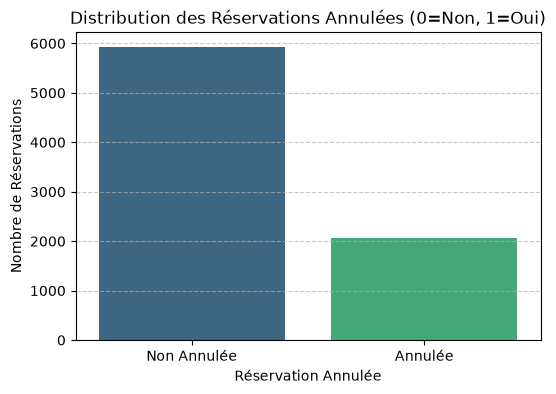

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualiser la distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='reservation_annulee', data=df_reservations, palette='viridis')
plt.title('Distribution des Réservations Annulées (0=Non, 1=Oui)')
plt.xlabel('Réservation Annulée')
plt.ylabel('Nombre de Réservations')
plt.xticks(ticks=[0, 1], labels=['Non Annulée', 'Annulée'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Justification des Traitements Appliqués à la Cible

Les étapes d'analyse de la variable cible `reservation_annulee` ont montré que :

1.  **Type de Données :** La variable est de type `int64`, ce qui est approprié pour une variable binaire (0 ou 1).
2.  **Valeurs Manquantes :** Il n'y a pas de valeurs manquantes (0 `null` values), donc aucun traitement spécifique n'est nécessaire à ce stade pour les valeurs manquantes.
3.  **Distribution :** La distribution de la variable cible sera examinée pour détecter un éventuel déséquilibre entre les classes 'Non Annulée' et 'Annulée'. Si un déséquilibre important est constaté, des techniques de rééchantillonnage (suréchantillonnage, sous-échantillonnage) pourraient être envisagées lors de la phase de modélisation pour garantir que le modèle ne soit pas biaisé vers la classe majoritaire.

Pour l'instant, la variable cible `reservation_annulee` est prête à être utilisée telle quelle pour les analyses ultérieures.

In [6]:
# Calculer le pourcentage de valeurs manquantes pour chaque colonne
missing_values_pct = df_reservations.isnull().sum() / len(df_reservations) * 100

# Afficher les colonnes avec des valeurs manquantes et leur pourcentage
missing_columns = missing_values_pct[missing_values_pct > 0].sort_values(ascending=False)
print("Pourcentage de valeurs manquantes par colonne :")
display(missing_columns)

Pourcentage de valeurs manquantes par colonne :


agent_id               41.9250
enfants                 4.4375
prix_moyen_nuit_eur     2.4125
marche_origine          2.3875
demandes_speciales      1.9625
dtype: float64

### Imputation des Valeurs Manquantes

Nous allons appliquer les stratégies d'imputation discutées précédemment.

In [7]:
# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations['agent_id'] = df_reservations['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations['enfants'] = df_reservations['enfants'].fillna(0)
df_reservations['demandes_speciales'] = df_reservations['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane
median_prix_moyen = df_reservations['prix_moyen_nuit_eur'].median()
df_reservations['prix_moyen_nuit_eur'] = df_reservations['prix_moyen_nuit_eur'].fillna(median_prix_moyen)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode
mode_marche_origine = df_reservations['marche_origine'].mode()[0]
df_reservations['marche_origine'] = df_reservations['marche_origine'].fillna(mode_marche_origine)

print("Vérification des valeurs manquantes après imputation :")
display(df_reservations.isnull().sum()[df_reservations.isnull().sum() > 0])

Vérification des valeurs manquantes après imputation :


Series([], dtype: int64)

### Analyse des Distributions et Détection des Valeurs Atypiques

Maintenant que les données sont nettoyées de leurs valeurs manquantes, nous allons examiner les distributions des différentes caractéristiques pour mieux les comprendre et identifier les éventuelles valeurs atypiques (outliers).

#### 1. Analyse des Variables Numériques

Nous allons visualiser la distribution de chaque variable numérique à l'aide d'histograms et de boxplots pour observer leur forme, leur asymétrie et détecter les valeurs aberrantes.

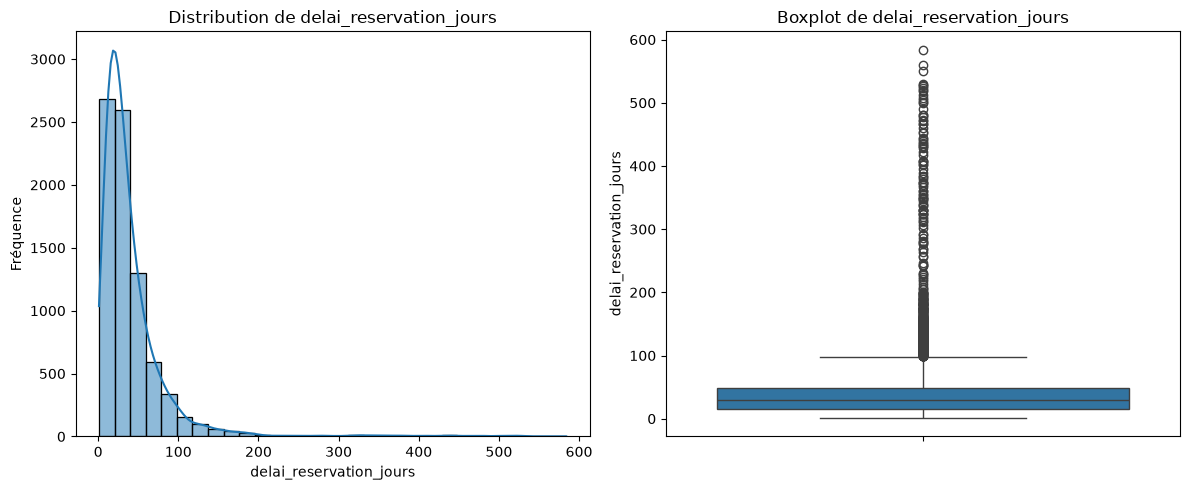

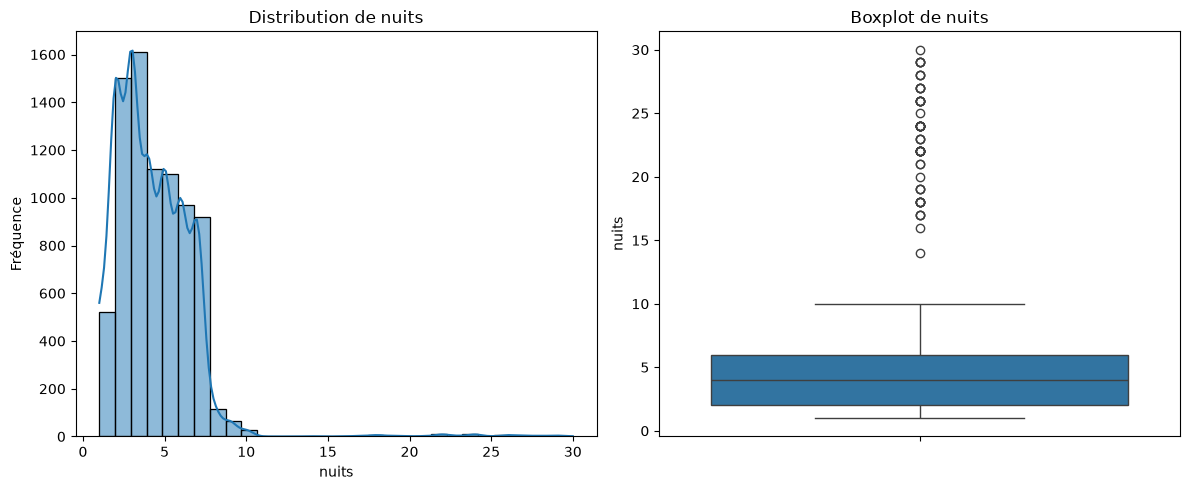

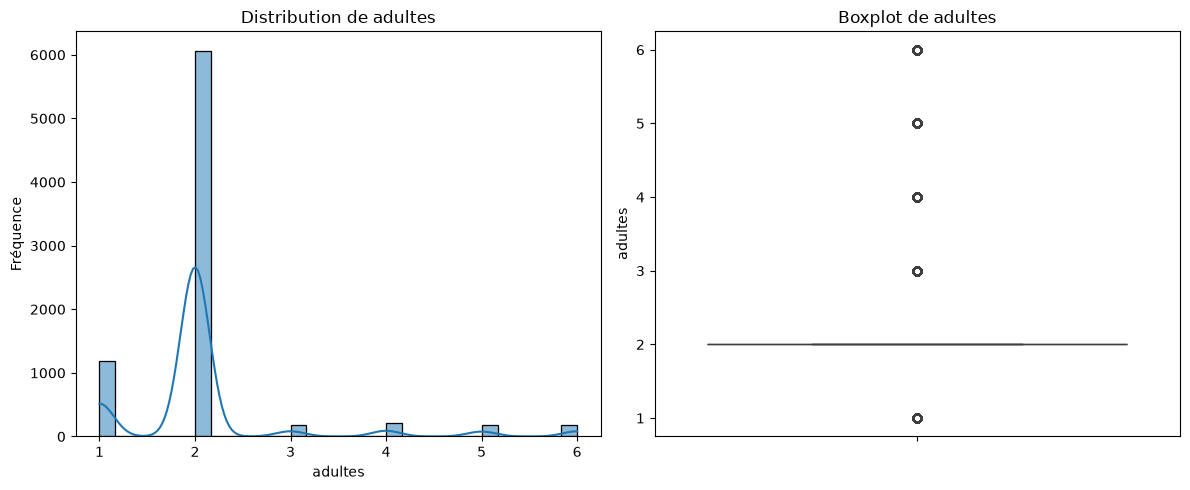

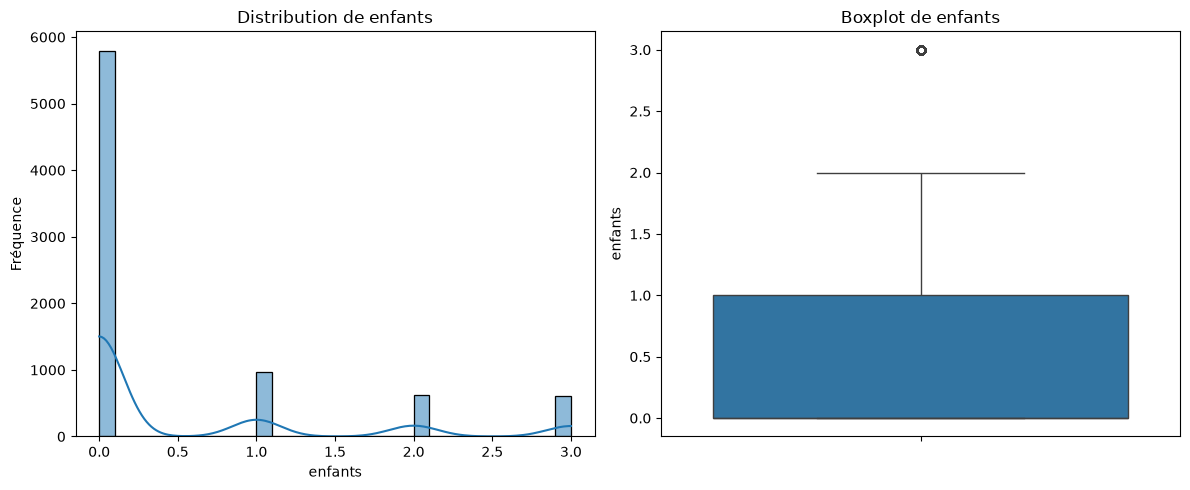

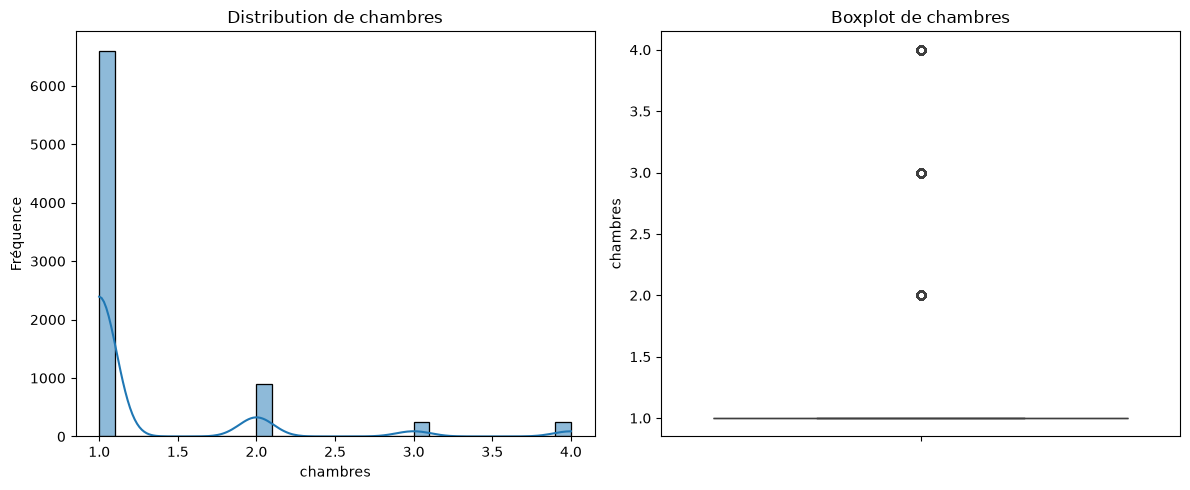

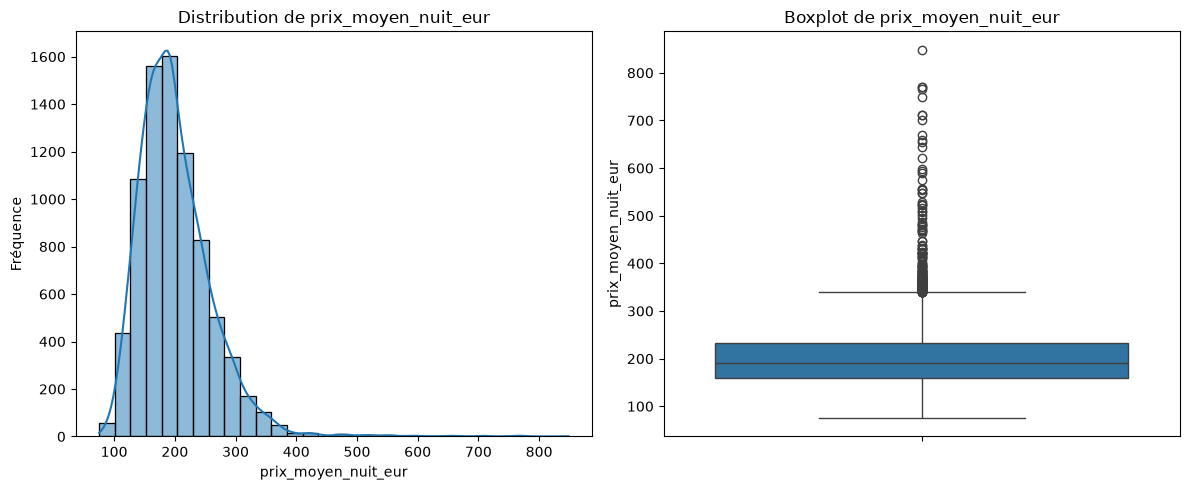

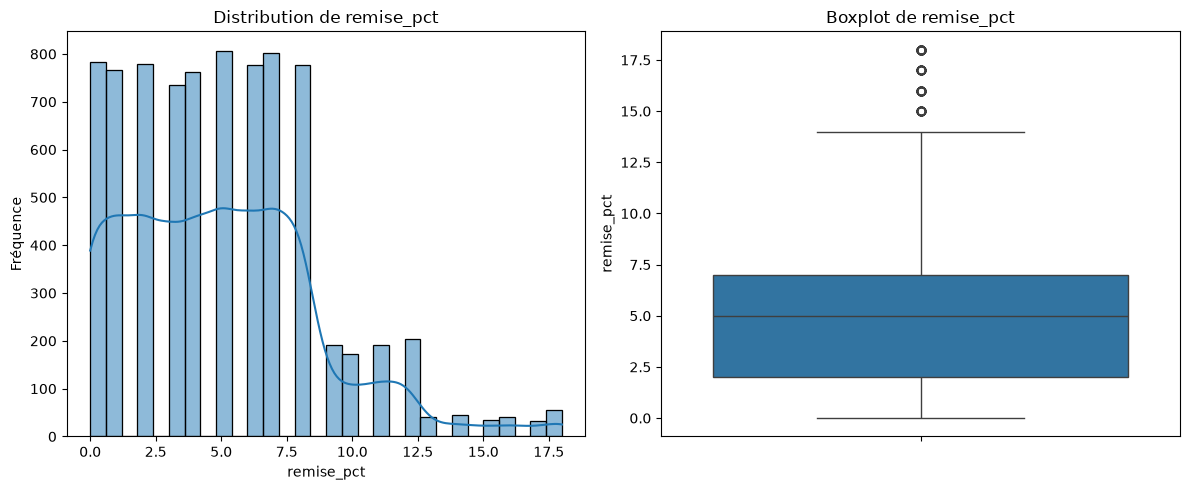

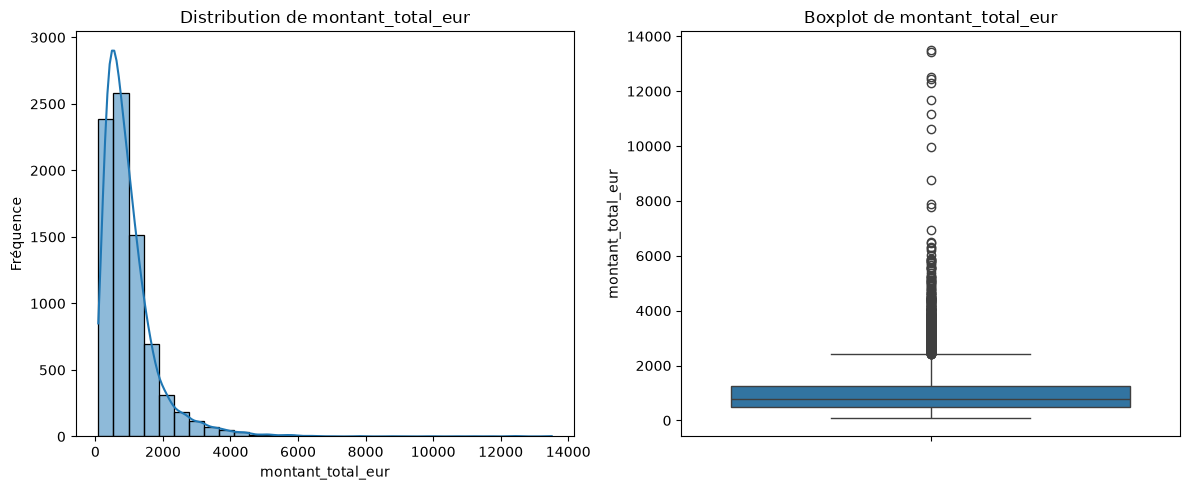

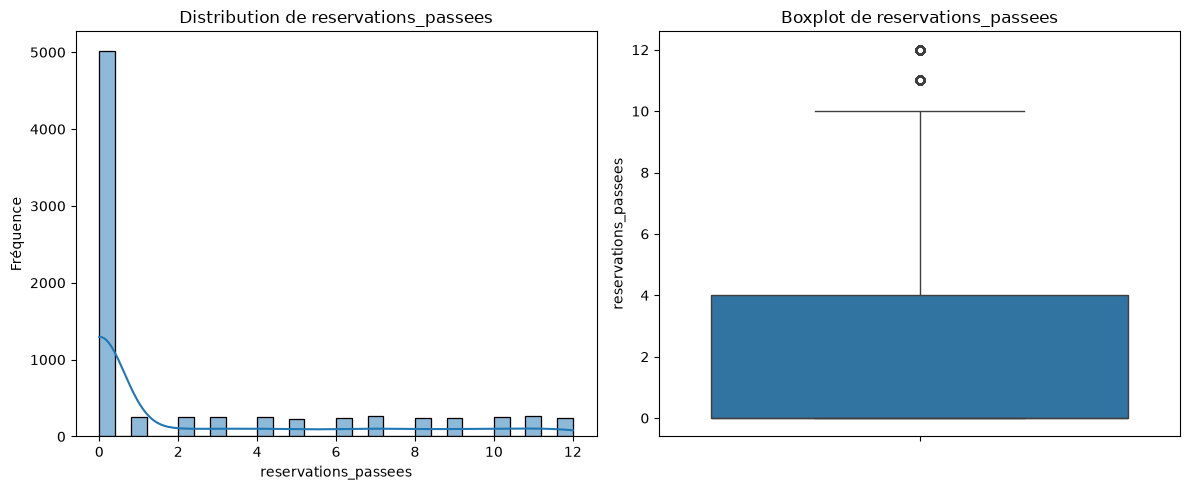

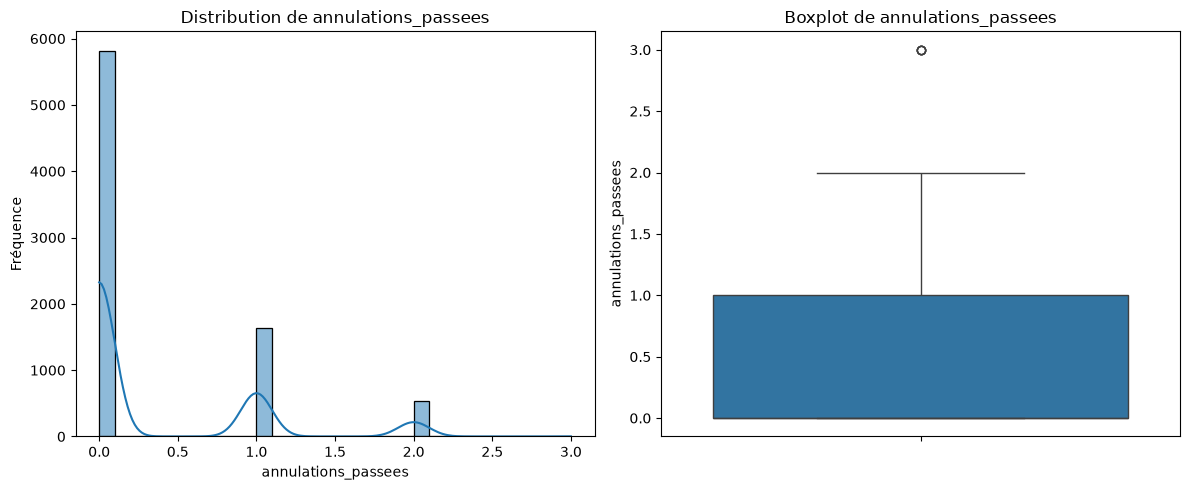

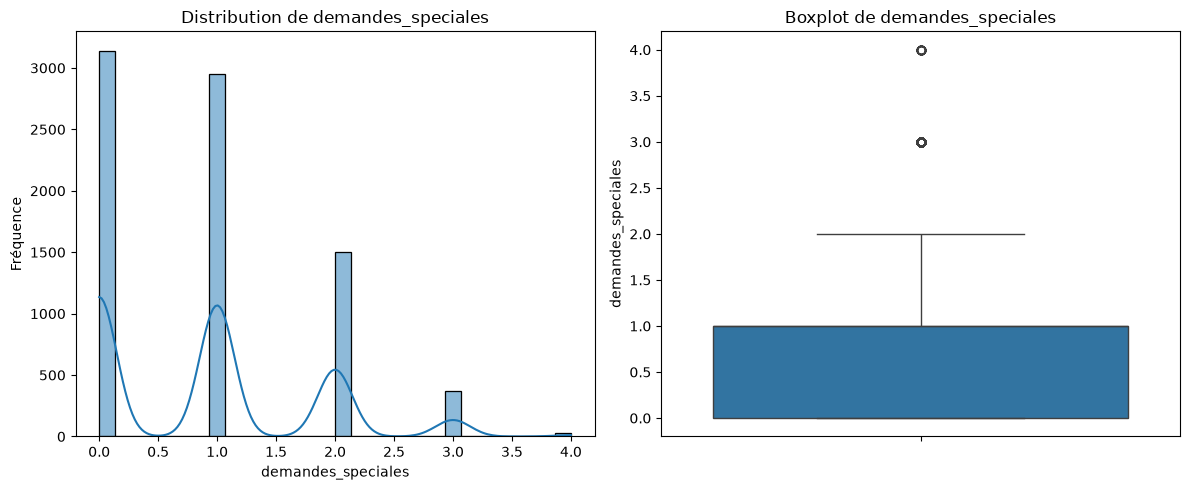

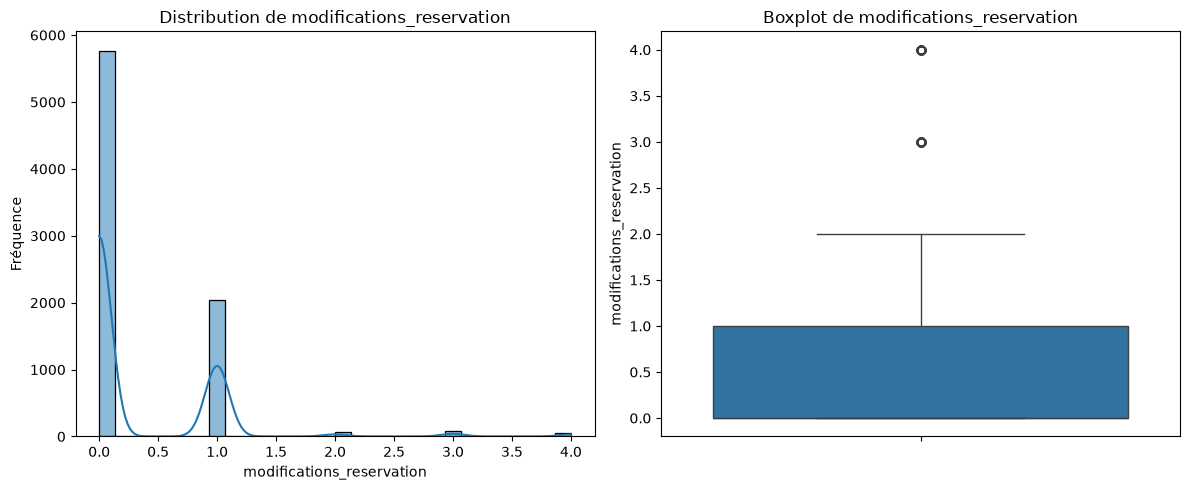

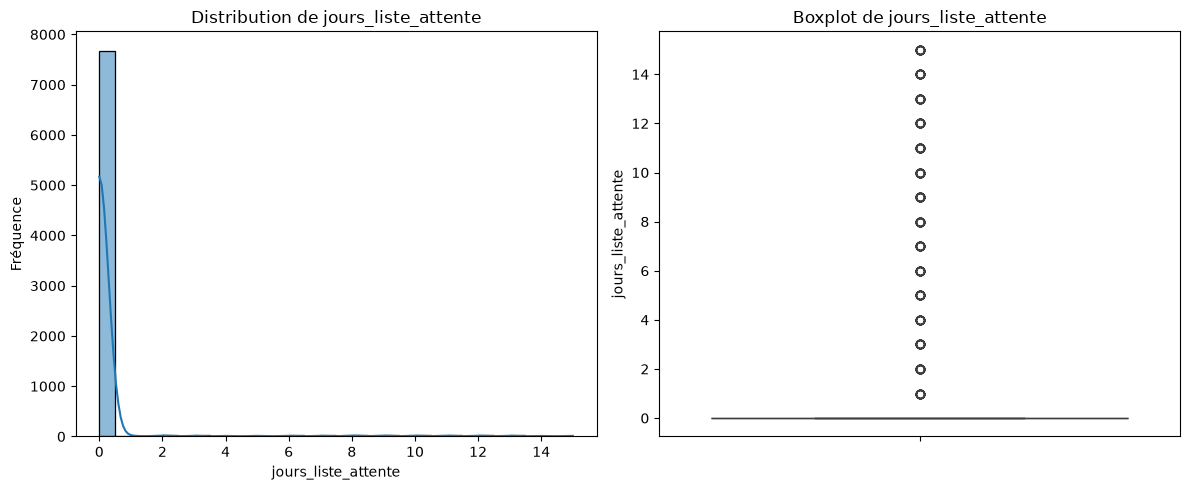

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes numériques (excluant les IDs et la cible déjà analysée)
numerical_cols = df_reservations.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['reservation_annulee', 'categorie_hotel', 'arrivee_weekend', 'evenement_majeur', 'haute_saison_regionale']]

# Filtrer les colonnes qui pourraient être considérées comme binaires/quasi-binaires
# 'categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend' sont plutôt catégorielles/binaires

for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogramme pour la distribution
    plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, 1er plot
    sns.histplot(df_reservations[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

    # Boxplot pour les outliers
    plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, 2ème plot
    sns.boxplot(y=df_reservations[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

#### 2. Analyse des Variables Catégorielles

Nous allons examiner la distribution de chaque variable catégorielle à l'aide de barres de comptage pour visualiser la fréquence de chaque catégorie.

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_reservations.select_dtypes(include='object').columns.tolist()
C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


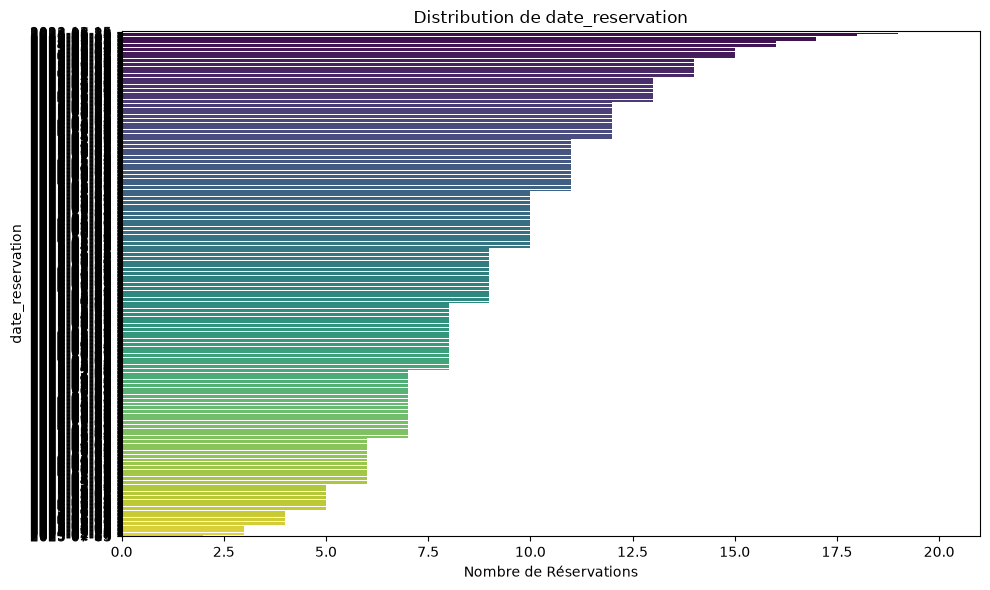

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


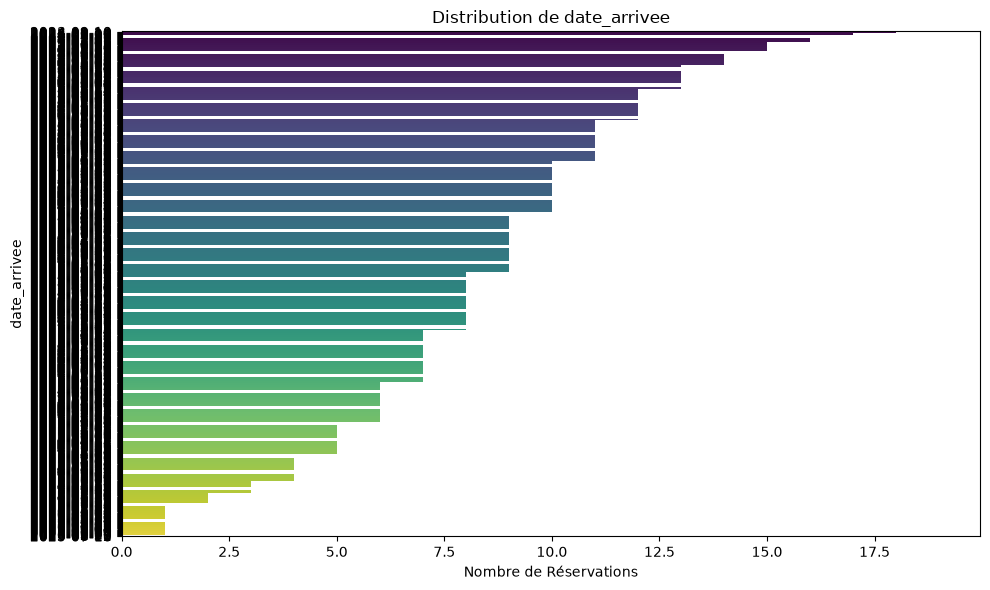

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


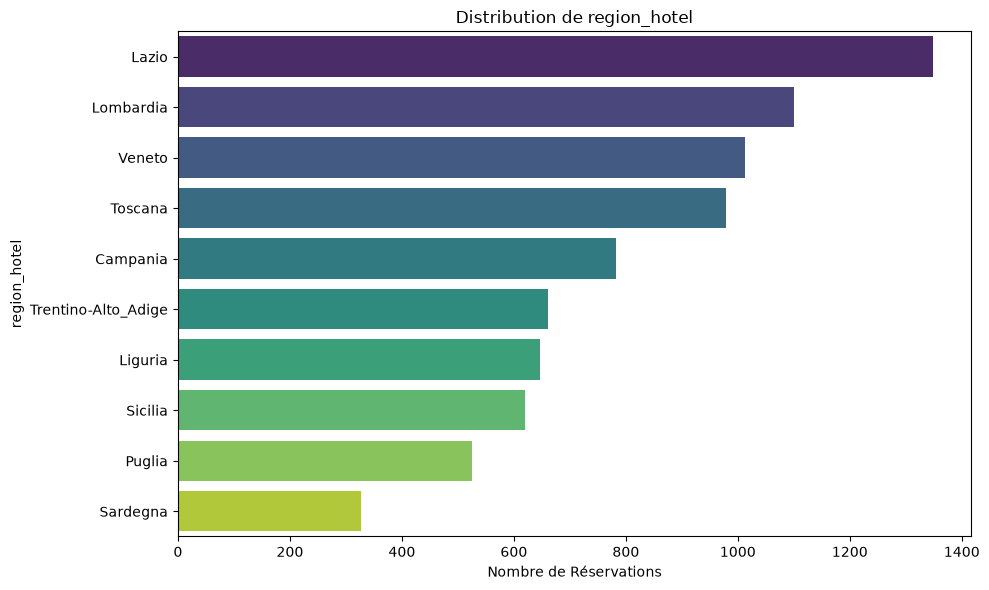

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


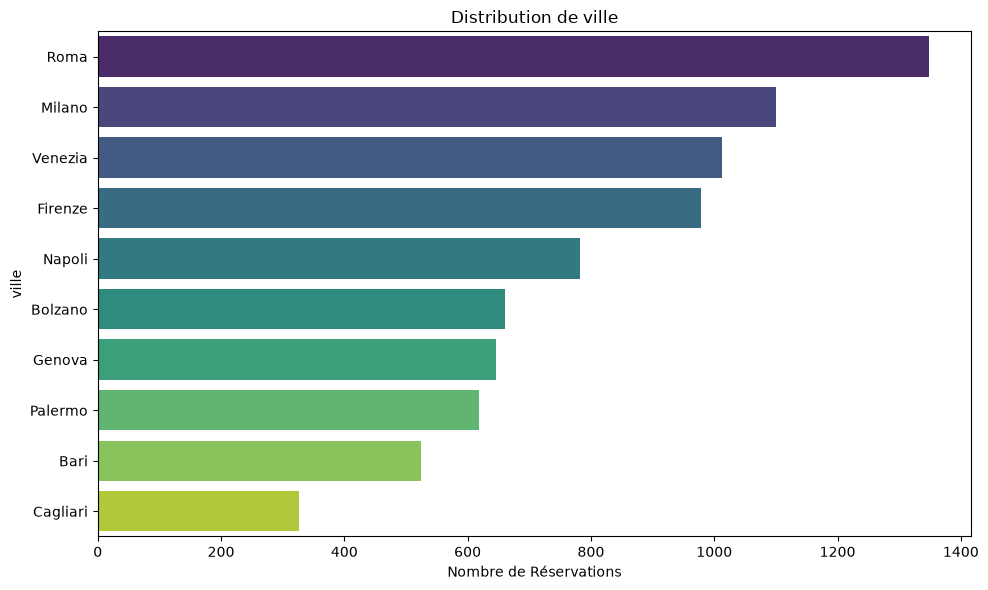

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


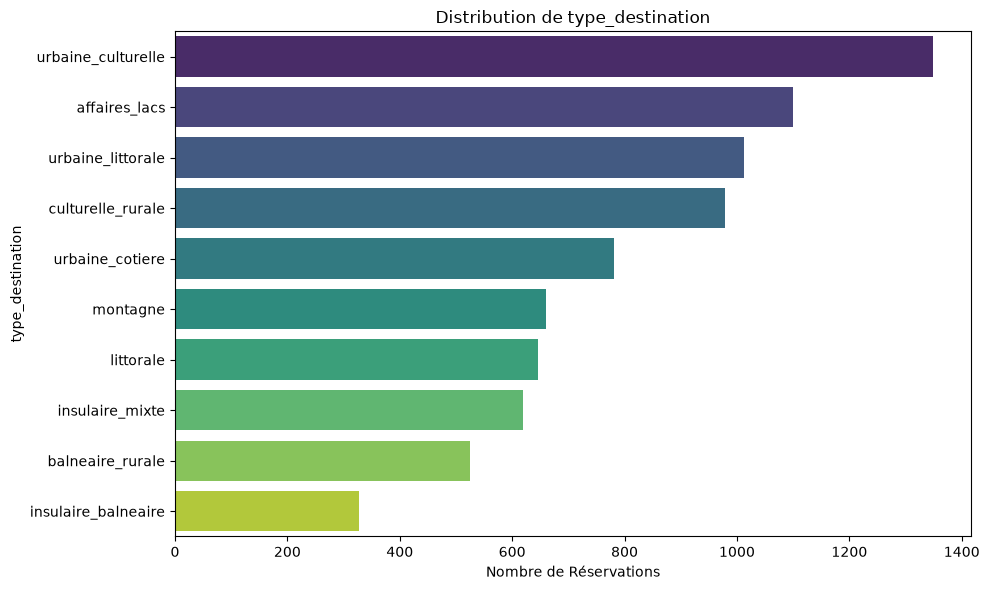

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


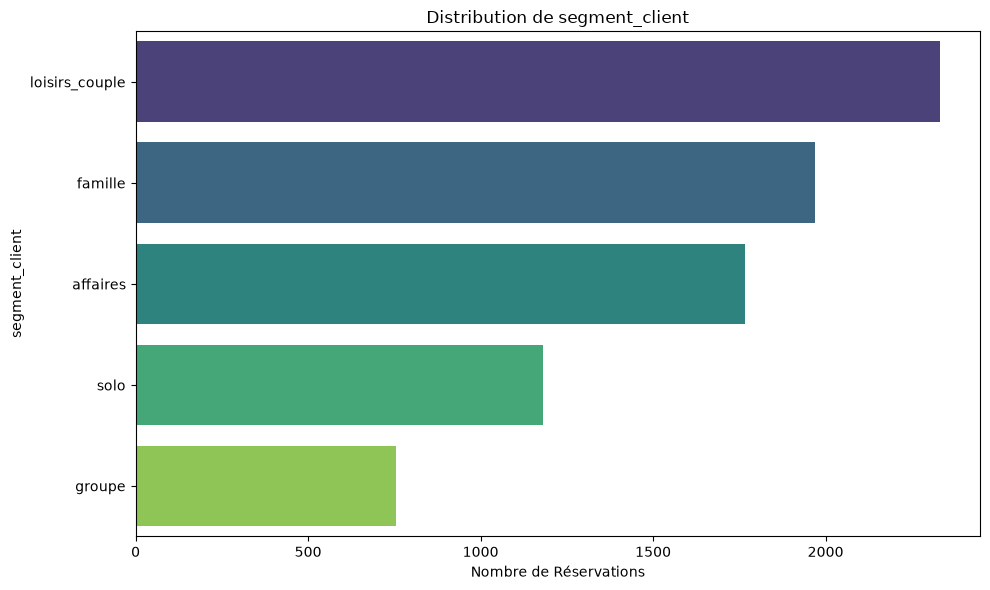

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


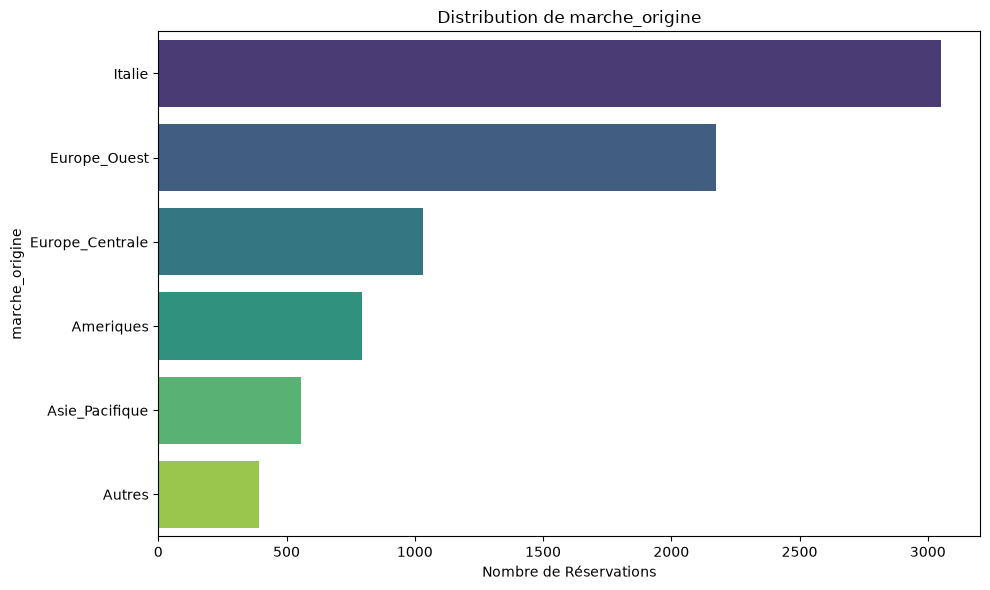

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


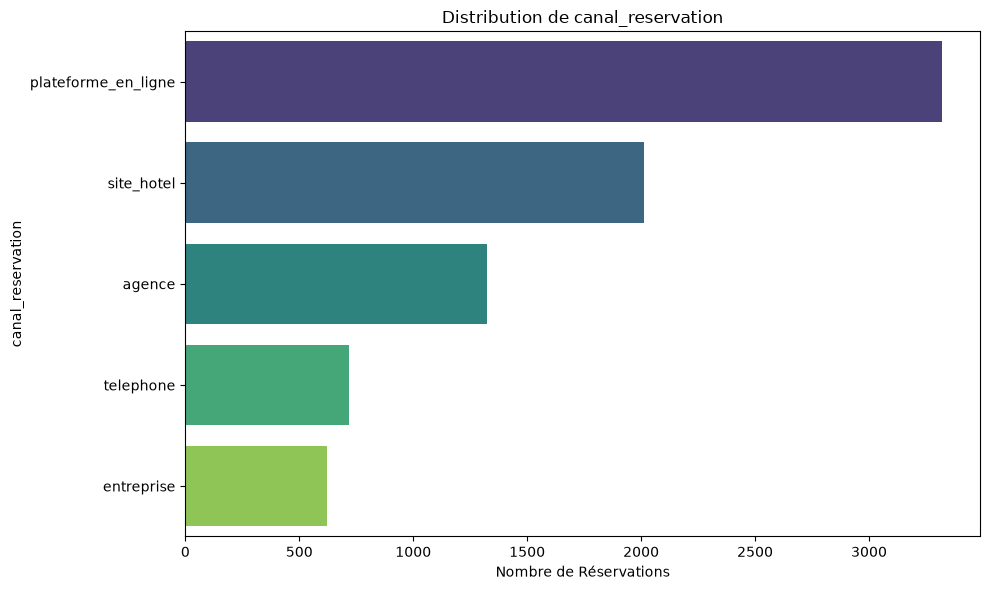

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


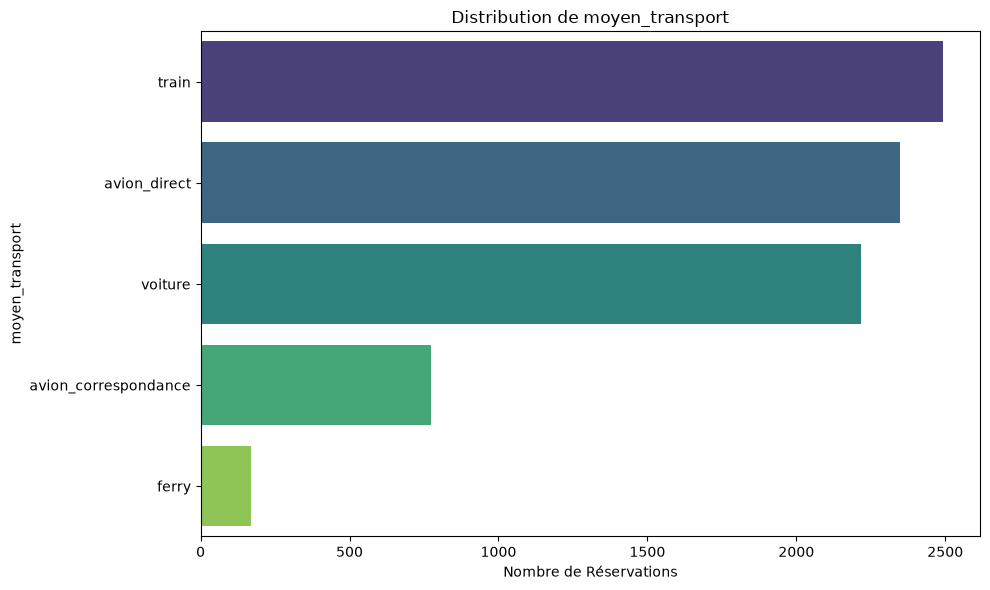

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


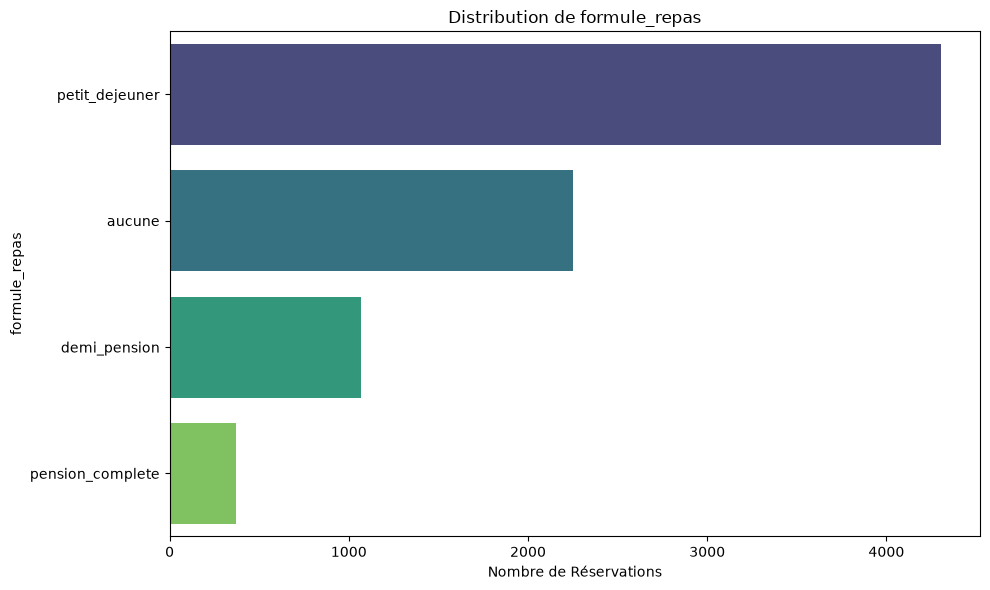

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


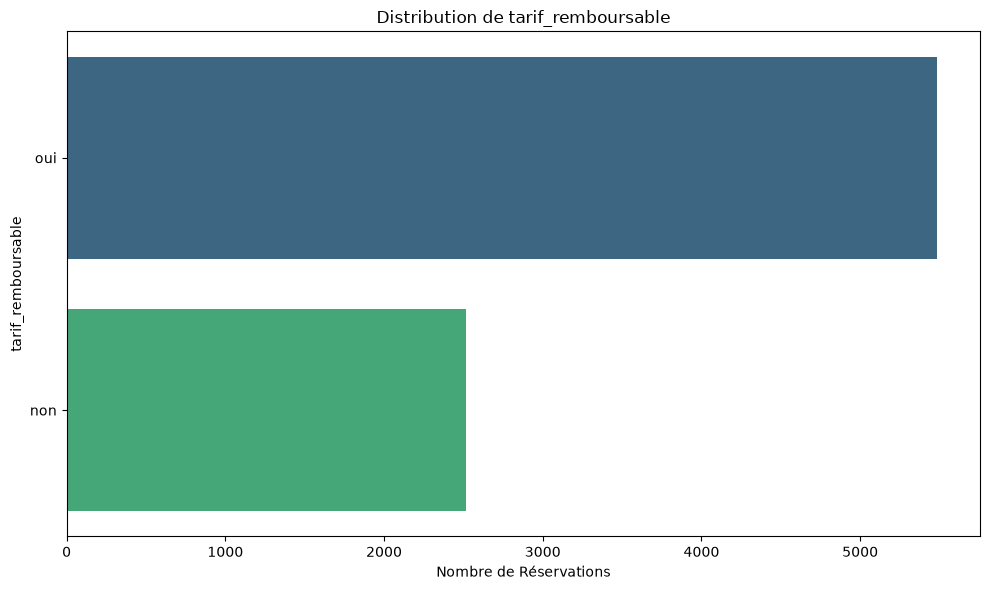

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


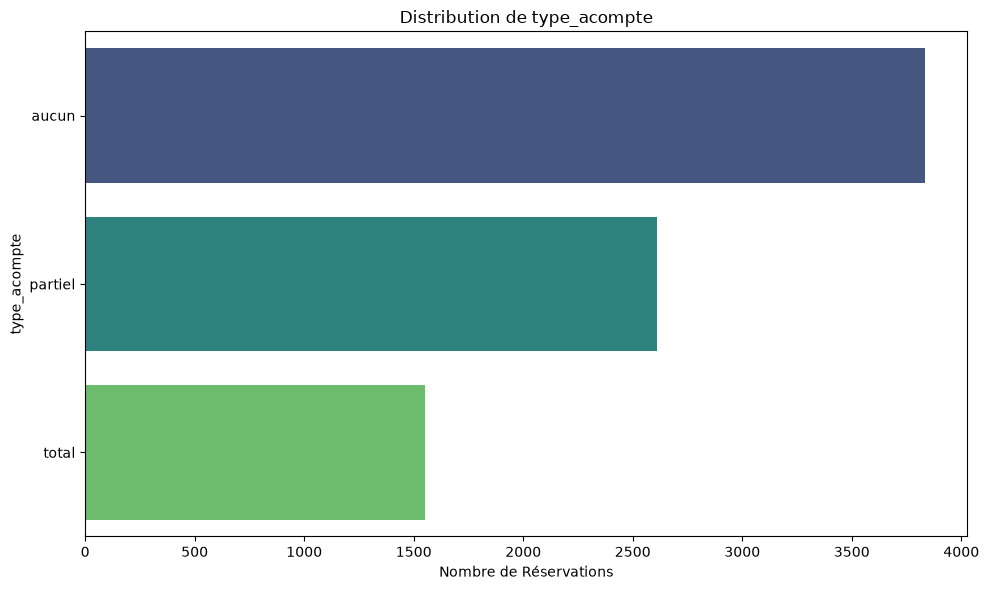

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


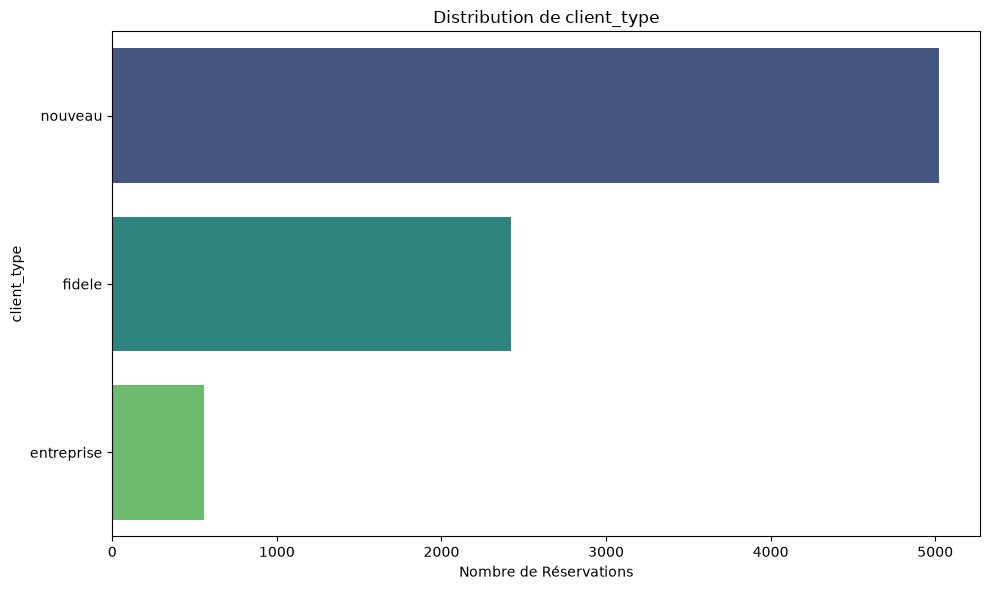

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


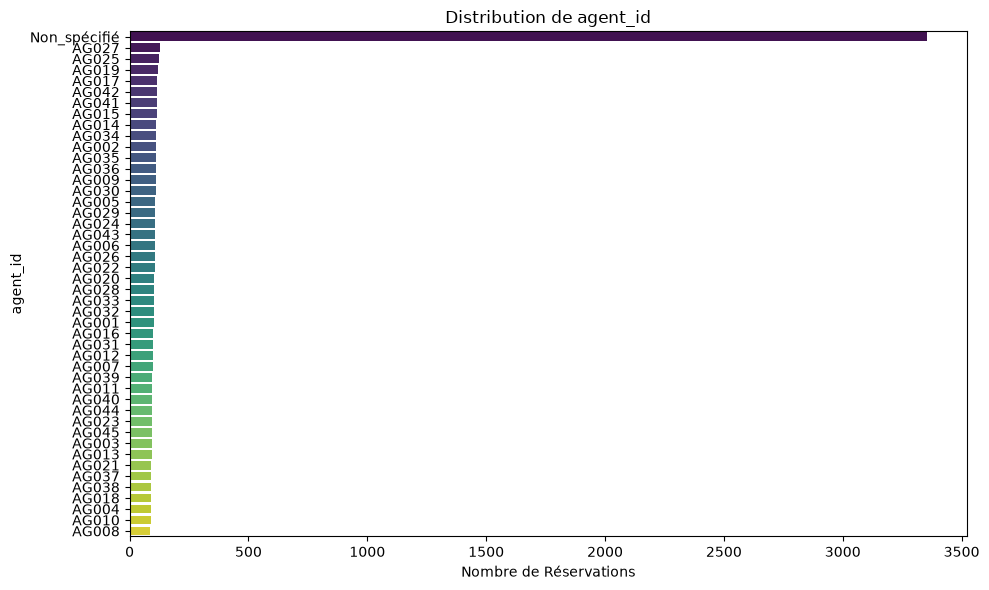

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


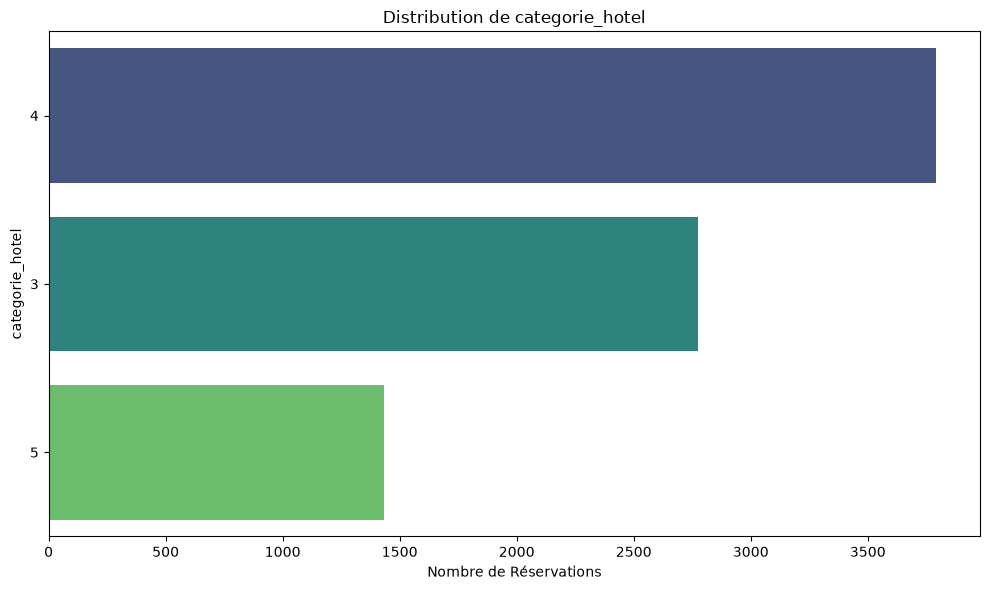

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


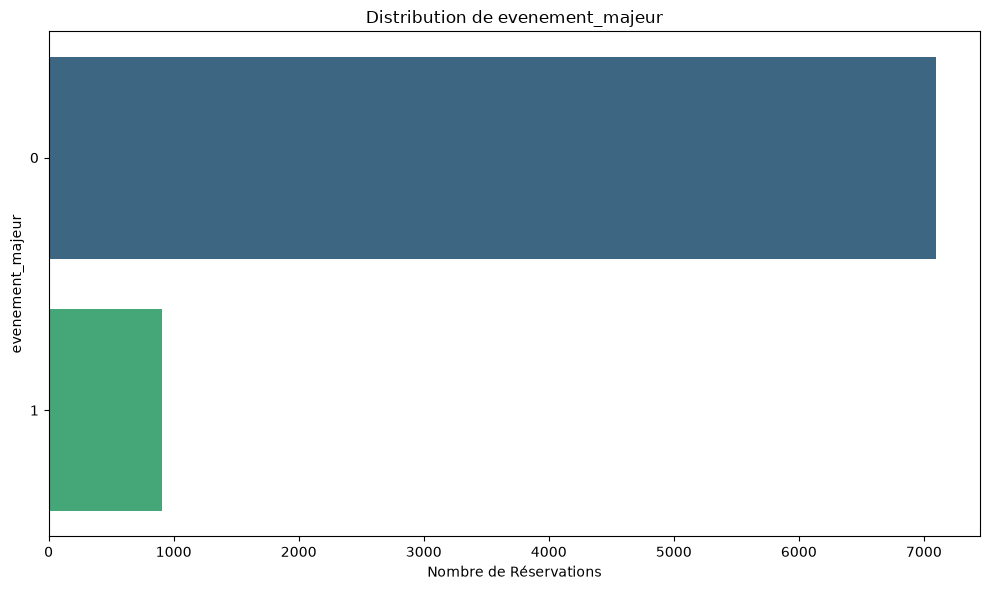

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


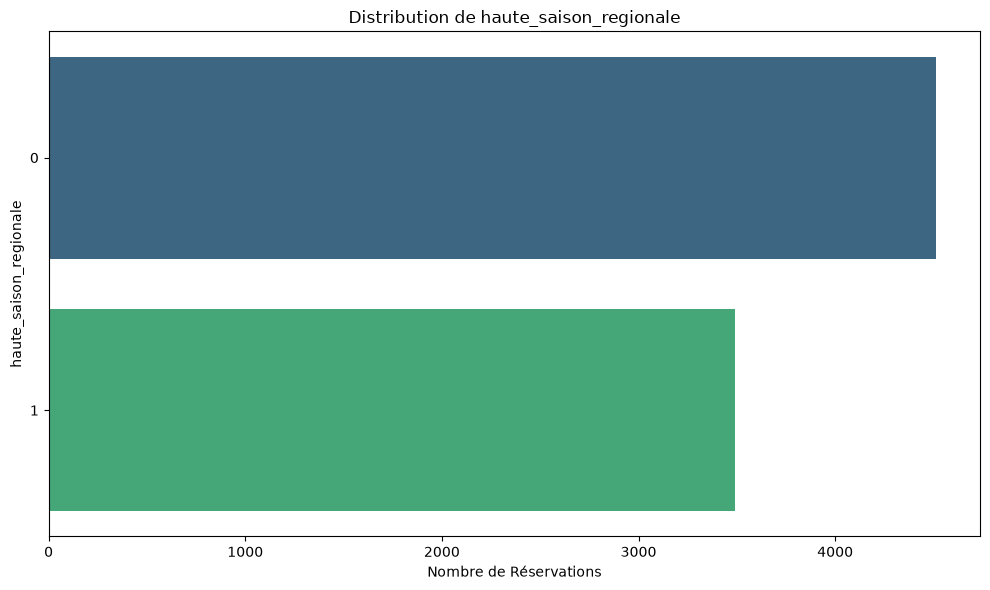

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\2965392459.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')


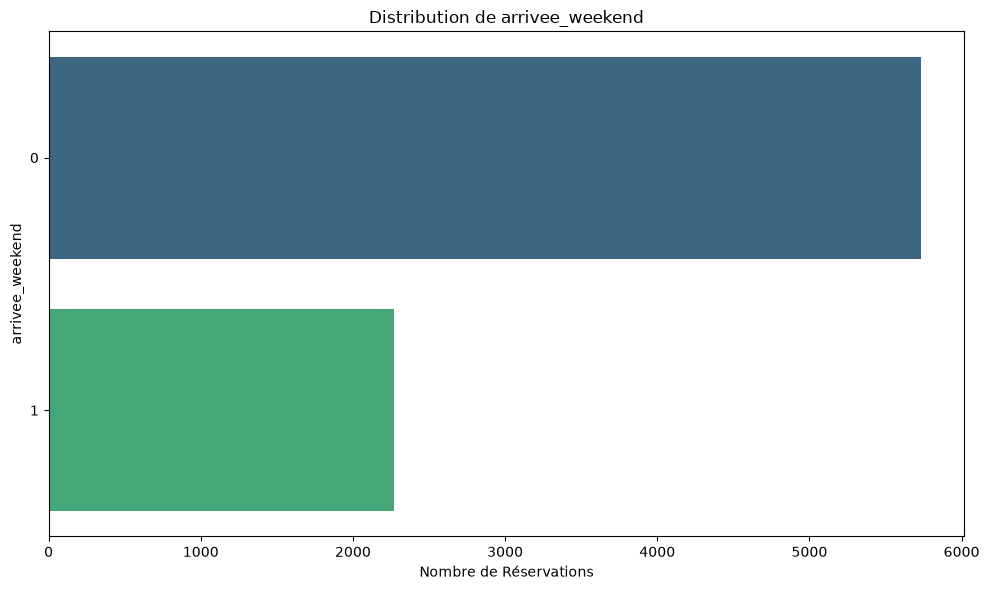

In [9]:
# Identifier les colonnes catégorielles (incluant les 'object' et les int64/float64 avec peu de valeurs uniques, comme les indicateurs)
categorical_cols = df_reservations.select_dtypes(include='object').columns.tolist()

# Ajouter les colonnes binaires/quasi-catégorielles exclues précédemment
categorical_cols.extend(['categorie_hotel', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend'])

# Exclure les IDs qui n'apportent pas d'information catégorielle utile pour la distribution
categorical_cols = [col for col in categorical_cols if col not in ['reservation_id', 'hotel_id']]

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_reservations[col], order=df_reservations[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution de {col}')
    plt.xlabel('Nombre de Réservations')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Extraction des Caractéristiques Temporelles

Nous allons extraire diverses caractéristiques temporelles des colonnes `date_reservation` et `date_arrivee` pour mieux comprendre les motifs saisonniers ou hebdomadaires qui pourraient influencer les annulations.

In [10]:
# Convertir les colonnes de date en format datetime
df_reservations['date_reservation'] = pd.to_datetime(df_reservations['date_reservation'])
df_reservations['date_arrivee'] = pd.to_datetime(df_reservations['date_arrivee'])

# Extraire des caractéristiques temporelles de la date de réservation
df_reservations['annee_reservation'] = df_reservations['date_reservation'].dt.year
df_reservations['mois_reservation'] = df_reservations['date_reservation'].dt.month
df_reservations['jour_semaine_reservation'] = df_reservations['date_reservation'].dt.dayofweek # Lundi=0, Dimanche=6
df_reservations['jour_annee_reservation'] = df_reservations['date_reservation'].dt.dayofyear

# Extraire des caractéristiques temporelles de la date d'arrivée
df_reservations['annee_arrivee'] = df_reservations['date_arrivee'].dt.year
df_reservations['mois_arrivee'] = df_reservations['date_arrivee'].dt.month
df_reservations['jour_semaine_arrivee'] = df_reservations['date_arrivee'].dt.dayofweek # Lundi=0, Dimanche=6
df_reservations['jour_annee_arrivee'] = df_reservations['date_arrivee'].dt.dayofyear

print("Nouvelles caractéristiques temporelles extraites.")
print(df_reservations[['date_reservation', 'date_arrivee', 'annee_reservation', 'mois_reservation', 'jour_semaine_reservation', 'annee_arrivee', 'mois_arrivee', 'jour_semaine_arrivee']].head())

Nouvelles caractéristiques temporelles extraites.
  date_reservation date_arrivee  annee_reservation  mois_reservation  \
0       2023-01-01   2023-03-13               2023                 1   
1       2023-01-01   2023-01-07               2023                 1   
2       2023-01-01   2023-03-26               2023                 1   
3       2023-01-01   2023-01-09               2023                 1   
4       2023-01-01   2023-01-11               2023                 1   

   jour_semaine_reservation  annee_arrivee  mois_arrivee  jour_semaine_arrivee  
0                         6           2023             3                     0  
1                         6           2023             1                     5  
2                         6           2023             3                     6  
3                         6           2023             1                     0  
4                         6           2023             1                     2  


### Analyse de la Tendance des Annulations par Caractéristiques Temporelles

Visualisons maintenant la proportion d'annulations en fonction de ces nouvelles caractéristiques temporelles.

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\100435772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temporal_col, y='reservation_annulee', data=cancellation_rate, palette='coolwarm')


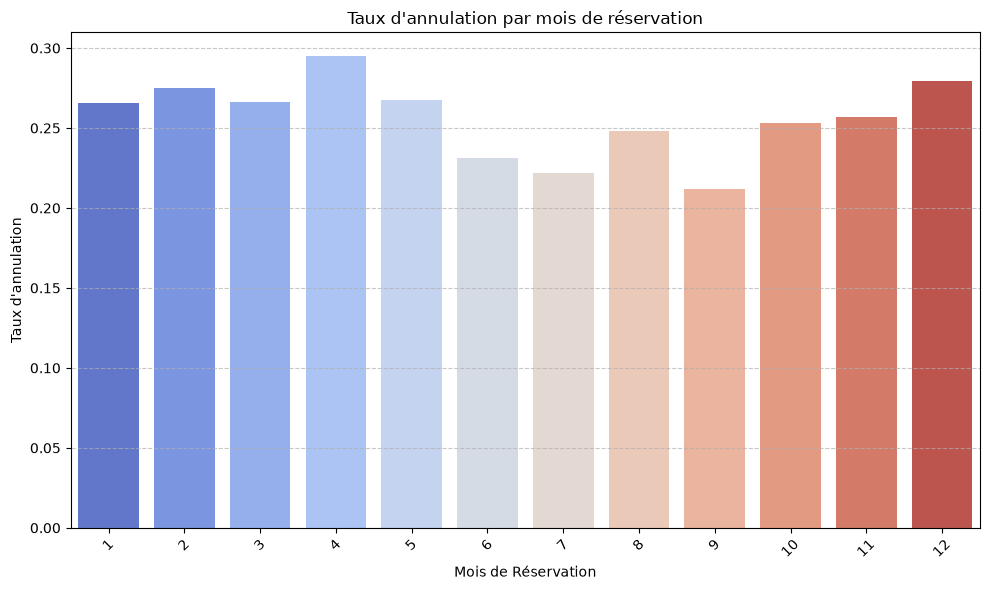

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\100435772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temporal_col, y='reservation_annulee', data=cancellation_rate, palette='coolwarm')


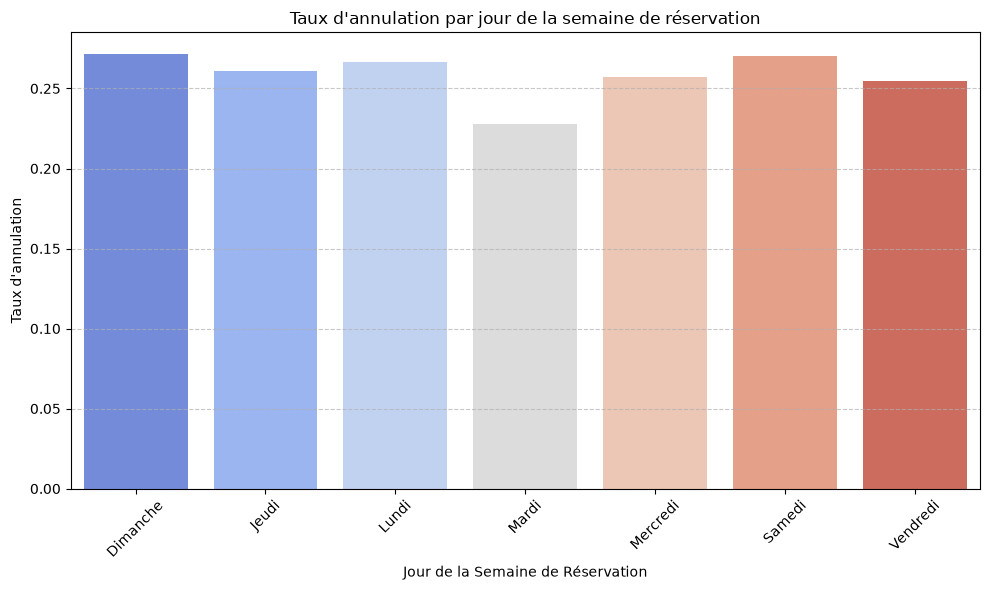

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\100435772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temporal_col, y='reservation_annulee', data=cancellation_rate, palette='coolwarm')


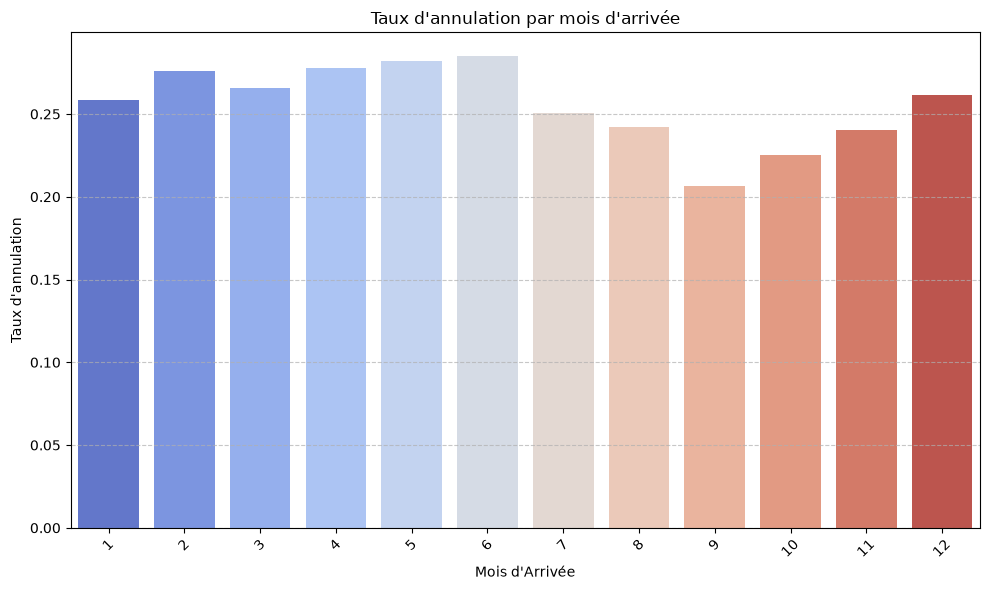

C:\Users\Nathalie\AppData\Local\Temp\ipykernel_14728\100435772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temporal_col, y='reservation_annulee', data=cancellation_rate, palette='coolwarm')


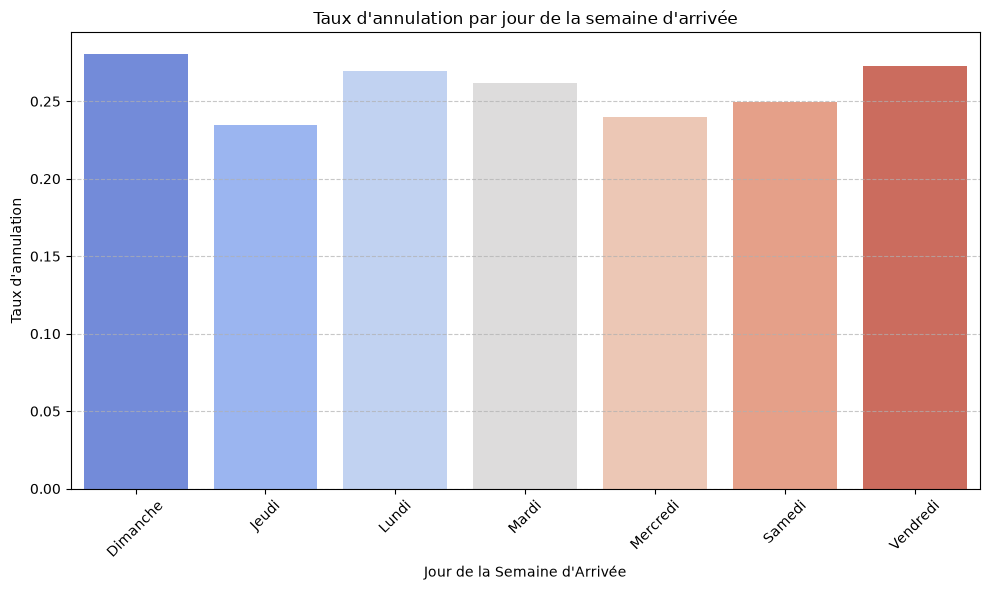

In [11]:
# Fonction pour visualiser le taux d'annulation par caractéristique temporelle
def plot_cancellation_rate(df, temporal_col, title, x_label):
    cancellation_rate = df.groupby(temporal_col)['reservation_annulee'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=temporal_col, y='reservation_annulee', data=cancellation_rate, palette='coolwarm')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Taux d\'annulation')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Taux d'annulation par mois de réservation
plot_cancellation_rate(df_reservations, 'mois_reservation', 'Taux d\'annulation par mois de réservation', 'Mois de Réservation')

# Taux d'annulation par jour de la semaine de réservation
day_names = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
df_reservations['jour_semaine_reservation_nom'] = df_reservations['jour_semaine_reservation'].map(lambda x: day_names[x])
plot_cancellation_rate(df_reservations, 'jour_semaine_reservation_nom', 'Taux d\'annulation par jour de la semaine de réservation', 'Jour de la Semaine de Réservation')

# Taux d'annulation par mois d'arrivée
plot_cancellation_rate(df_reservations, 'mois_arrivee', 'Taux d\'annulation par mois d\'arrivée', 'Mois d\'Arrivée')

# Taux d'annulation par jour de la semaine d'arrivée
df_reservations['jour_semaine_arrivee_nom'] = df_reservations['jour_semaine_arrivee'].map(lambda x: day_names[x])
plot_cancellation_rate(df_reservations, 'jour_semaine_arrivee_nom', 'Taux d\'annulation par jour de la semaine d\'arrivée', 'Jour de la Semaine d\'Arrivée')

### Régression Logistique sur les Données Brutes (avant Feature Engineering)

Suite à votre demande, nous allons entraîner un nouveau modèle de régression logistique en utilisant les données après l'imputation des valeurs manquantes, mais *avant* toute l'ingénierie des caractéristiques temporelles ou des ratios que nous avons effectuées précédemment. Cela nous permettra d'évaluer la performance du modèle sur un ensemble de caractéristiques plus basique.

#### Réapplication de l'Imputation des Valeurs Manquantes

Nous réappliquons les mêmes stratégies d'imputation que précédemment pour nettoyer le DataFrame rechargé.

In [12]:

# Réappliquer l'imputation des valeurs manquantes
df_reservations_clean = df_reservations.copy()

# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations_clean['agent_id'] = df_reservations_clean['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations_clean['enfants'] = df_reservations_clean['enfants'].fillna(0)
df_reservations_clean['demandes_speciales'] = df_reservations_clean['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane
median_prix_moyen = df_reservations_clean['prix_moyen_nuit_eur'].median()
df_reservations_clean['prix_moyen_nuit_eur'] = df_reservations_clean['prix_moyen_nuit_eur'].fillna(median_prix_moyen)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode
mode_marche_origine = df_reservations_clean['marche_origine'].mode()[0]
df_reservations_clean['marche_origine'] = df_reservations_clean['marche_origine'].fillna(mode_marche_origine)

# Convertir les colonnes de date au format datetime (nécessaire pour les exclure plus tard si elles ne sont pas features)
df_reservations_clean['date_reservation'] = pd.to_datetime(df_reservations_clean['date_reservation'])
df_reservations_clean['date_arrivee'] = pd.to_datetime(df_reservations_clean['date_arrivee'])

print("Valeurs manquantes réimputées et dates converties.")

Valeurs manquantes réimputées et dates converties.


#### Préparation des Données (Encodage et Mise à l'Échelle)

Nous allons séparer les caractéristiques et la cible, puis appliquer l'encodage One-Hot aux variables catégorielles et la mise à l'échelle aux variables numériques, sans créer de nouvelles caractéristiques.

In [13]:
# Réappliquer l'imputation des valeurs manquantes
df_reservations_clean = df_reservations.copy()

# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations_clean['agent_id'] = df_reservations_clean['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations_clean['enfants'] = df_reservations_clean['enfants'].fillna(0)
df_reservations_clean['demandes_speciales'] = df_reservations_clean['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane
median_prix_moyen = df_reservations_clean['prix_moyen_nuit_eur'].median()
df_reservations_clean['prix_moyen_nuit_eur'] = df_reservations_clean['prix_moyen_nuit_eur'].fillna(median_prix_moyen)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode
mode_marche_origine = df_reservations_clean['marche_origine'].mode()[0]
df_reservations_clean['marche_origine'] = df_reservations_clean['marche_origine'].fillna(mode_marche_origine)

# Convertir les colonnes de date au format datetime (nécessaire pour les exclure plus tard si elles ne sont pas features)
df_reservations_clean['date_reservation'] = pd.to_datetime(df_reservations_clean['date_reservation'])
df_reservations_clean['date_arrivee'] = pd.to_datetime(df_reservations_clean['date_arrivee'])

print("Valeurs manquantes réimputées et dates converties (train).")

# ============================================================
# Appliquer la même imputation sur le jeu de test
# (on réutilise les valeurs calculées sur le train pour éviter toute fuite de données)
# ============================================================
df_reservations_test_clean = df_reservations_test.copy()

# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations_test_clean['agent_id'] = df_reservations_test_clean['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations_test_clean['enfants'] = df_reservations_test_clean['enfants'].fillna(0)
df_reservations_test_clean['demandes_speciales'] = df_reservations_test_clean['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane du TRAIN
df_reservations_test_clean['prix_moyen_nuit_eur'] = df_reservations_test_clean['prix_moyen_nuit_eur'].fillna(median_prix_moyen)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode du TRAIN
df_reservations_test_clean['marche_origine'] = df_reservations_test_clean['marche_origine'].fillna(mode_marche_origine)

# Convertir les colonnes de date au format datetime
df_reservations_test_clean['date_reservation'] = pd.to_datetime(df_reservations_test_clean['date_reservation'])
df_reservations_test_clean['date_arrivee'] = pd.to_datetime(df_reservations_test_clean['date_arrivee'])

print("Valeurs manquantes réimputées et dates converties (test).")

# ============================================================
# Création de X_raw / y_raw à partir de df_reservations_clean
# puis split train/validation en conservant l'ordre chronologique
# (sans train_test_split)
# ============================================================

# ⚠️ Ajuste 'statut_reservation' avec le nom exact de ta colonne cible si besoin
target_col = 'reservation_annulee'

# Colonnes à exclure des features (cible + colonnes de date brutes non transformées)
cols_to_drop = [target_col, 'date_reservation', 'date_arrivee']

X_raw = df_reservations_clean.drop(columns=cols_to_drop)
y_raw = df_reservations_clean[target_col]

# Split ordonné (80% train / 20% validation), sans mélange
split_ratio = 0.8
split_index = int(len(X_raw) * split_ratio)

X_train_raw, X_val_raw = X_raw.iloc[:split_index], X_raw.iloc[split_index:]
y_train_raw, y_val_raw = y_raw.iloc[:split_index], y_raw.iloc[split_index:]

print(f"Taille X_train_raw: {X_train_raw.shape}, X_val_raw: {X_val_raw.shape}")
print(f"Taille y_train_raw: {y_train_raw.shape}, y_val_raw: {y_val_raw.shape}")

Valeurs manquantes réimputées et dates converties (train).
Valeurs manquantes réimputées et dates converties (test).
Taille X_train_raw: (6400, 41), X_val_raw: (1600, 41)
Taille y_train_raw: (6400,), y_val_raw: (1600,)


#### Entraînement du Modèle de Régression Logistique

In [14]:
!pip install optuna

import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# 1. Désactiver les logs verbeux d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Fonction objectif pour Optuna
def objective(trial):
    c = trial.suggest_float('C', 1e-3, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])

    model = LogisticRegression(
        C=c,
        penalty=penalty,
        solver=solver,
        class_weight=class_weight,
        max_iter=1000,
        random_state=42
    )

    # Évaluation par F1-score en validation croisée sur le jeu d'entraînement
    score = cross_val_score(model, X_train_raw, y_train_raw, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

# 3. Lancement de l'optimisation Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Meilleurs hyperparamètres : {study.best_params}")
print(f"Meilleur F1-Score (CV Train) : {study.best_value:.4f}\n")

# 4. Entraînement du modèle final avec les meilleurs hyperparamètres
best_lr_model = LogisticRegression(
    **study.best_params,
    max_iter=1000,
    random_state=42
)
best_lr_model.fit(X_train_raw, y_train_raw)

# 5. Prédictions sur le jeu de validation
lr_y_pred = best_lr_model.predict(X_val_raw)
lr_y_proba = best_lr_model.predict_proba(X_val_raw)[:, 1]

# 6. Calcul des métriques d'évaluation
lr_accuracy = accuracy_score(y_val_raw, lr_y_pred)
lr_precision = precision_score(y_val_raw, lr_y_pred)
lr_recall = recall_score(y_val_raw, lr_y_pred)
lr_f1 = f1_score(y_val_raw, lr_y_pred)
lr_roc_auc = roc_auc_score(y_val_raw, lr_y_proba)

print("--- Résultats de la Régression Logistique Optimisée (Validation) ---")
print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall   : {lr_recall:.4f}")
print(f"Logistic Regression F1-Score : {lr_f1:.4f}")
print(f"Logistic Regression AUC-ROC  : {lr_roc_auc:.4f}")

# 7. Affichage de la matrice de confusion
lr_cm = confusion_matrix(y_val_raw, lr_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    lr_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non Annulé (0)', 'Annulé (1)'],
    yticklabels=['Non Annulé (0)', 'Annulé (1)']
)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Régression Logistique Optimisée Optuna)')
plt.show()

c:\Users\Nathalie\Desktop\Atlantic-Haven-Exam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[W 2026-08-13 16:43:41,611] Trial 0 failed with parameters: {'C': 0.25617418280412935, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None} because of the following error: ValueError('\nAll the 5 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n1 fits failed with the following error:\nTraceback (most recent call last):\n  File "c:\\Users\\Nathalie\\Desktop\\Atlantic-Haven-Exam\\.venv\\Lib\\site-packages\\sklearn\\model_selection\\_validation.py", line 856, in _fit_and_score\n    estimator.fit(X_trai

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Nathalie\Desktop\Atlantic-Haven-Exam\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Nathalie\Desktop\Atlantic-Haven-Exam\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Nathalie\Desktop\Atlantic-Haven-Exam\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1459, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "c:\Users\Nathalie\Desktop\Atlantic-Haven-E

#Autre famille de model XGBOOST, LightBGM, Random Forest

In [ ]:
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# 1. Définition de la fonction objectif pour Optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,

        # Complexité de l'arbre et apprentissage
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),

        # Régularisation et sous-échantillonnage (anti-overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        # Poids de la classe positive pour maximiser le F1-score
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0)
    }

    # Entraînement sur X_train_raw
    model = LGBMClassifier(**params)
    model.fit(X_train_raw, y_train_raw)

    # Évaluation sur le jeu de validation temporel X_val_raw
    y_pred_val = model.predict(X_val_raw)
    score = f1_score(y_val_raw, y_pred_val)

    return score

# 2. Création et lancement de l'étude Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

# 3. Affichage des résultats de l'optimisation
print(f"Meilleur F1-Score (Validation) : {study.best_value:.4f}")
print("\nMeilleurs hyperparamètres :")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")

# 4. Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['verbose'] = -1

best_lgb_model = LGBMClassifier(**best_params)
best_lgb_model.fit(X_train_raw, y_train_raw)

# 5. Prédictions sur le jeu de validation
lgb_y_pred = best_lgb_model.predict(X_val_raw)
lgb_y_proba = best_lgb_model.predict_proba(X_val_raw)[:, 1]

# 6. Calcul des métriques d'évaluation
lgb_accuracy = accuracy_score(y_val_raw, lgb_y_pred)
lgb_precision = precision_score(y_val_raw, lgb_y_pred)
lgb_recall = recall_score(y_val_raw, lgb_y_pred)
lgb_f1 = f1_score(y_val_raw, lgb_y_pred)
lgb_roc_auc = roc_auc_score(y_val_raw, lgb_y_proba)

print("\n--- Résultats de LightGBM Optimisé (Validation) ---")
print(f"LightGBM Accuracy : {lgb_accuracy:.4f}")
print(f"LightGBM Precision: {lgb_precision:.4f}")
print(f"LightGBM Recall   : {lgb_recall:.4f}")
print(f"LightGBM F1-Score : {lgb_f1:.4f}")
print(f"LightGBM AUC-ROC  : {lgb_roc_auc:.4f}")

# 7. Affichage de la matrice de confusion
lgb_cm = confusion_matrix(y_val_raw, lgb_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    lgb_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non Annulé (0)', 'Annulé (1)'],
    yticklabels=['Non Annulé (0)', 'Annulé (1)']
)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (LightGBM Optimisé Optuna)')
plt.show()

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# 1. Définition de la fonction objectif pour Optuna
def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,

        # Structure de l'arbre et taux d'apprentissage
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 100, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),

        # Sous-échantillonnage des lignes et des colonnes (anti-overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5.0), # Gain minimal requis pour découper un nœud

        # Régularisation L1 (alpha) et L2 (lambda)
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),

        # Poids de la classe positive pour compenser le déséquilibre
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0)
    }

    # Entraînement sur X_train_raw
    model = XGBClassifier(**params)
    model.fit(X_train_raw, y_train_raw)

    # Évaluation sur la validation temporelle X_val_raw
    y_pred_val = model.predict(X_val_raw)
    score = f1_score(y_val_raw, y_pred_val)

    return score

# 2. Création et lancement de l'étude
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

# 3. Affichage des résultats
print(f"Meilleur F1-Score obtenu (XGBoost) : {study.best_value:.4f}")
print("\nMeilleurs hyperparamètres :")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")

# 4. Entraînement du modèle final
best_params = study.best_params
best_params['random_state'] = 42
best_xgb_model = XGBClassifier(**best_params)
best_xgb_model.fit(X_train_raw, y_train_raw)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Définition de la fonction objectif pour Optuna
def objective(trial):
    params = {
        'random_state': 42,
        'n_jobs': -1,

        # Structure de la forêt
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),

        # Sous-échantillonnage des colonnes (anti-overfitting)
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),

        # Bootstrap
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),

        # Poids des classes pour compenser le déséquilibre
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }

    # Entraînement sur X_train_raw
    model = RandomForestClassifier(**params)
    model.fit(X_train_raw, y_train_raw)

    # Évaluation sur la validation temporelle X_val_raw
    y_pred_val = model.predict(X_val_raw)
    score = f1_score(y_val_raw, y_pred_val)

    return score

# 2. Création et lancement de l'étude Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

# 3. Affichage des résultats de l'optimisation
print(f"Meilleur F1-Score (Validation) : {study.best_value:.4f}")
print("\nMeilleurs hyperparamètres :")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")

# 4. Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['n_jobs'] = -1

best_rf_model = RandomForestClassifier(**best_params)
best_rf_model.fit(X_train_raw, y_train_raw)

# 5. Prédictions sur le jeu de validation
rf_y_pred = best_rf_model.predict(X_val_raw)
rf_y_proba = best_rf_model.predict_proba(X_val_raw)[:, 1]

# 6. Calcul des métriques d'évaluation
rf_accuracy = accuracy_score(y_val_raw, rf_y_pred)
rf_precision = precision_score(y_val_raw, rf_y_pred)
rf_recall = recall_score(y_val_raw, rf_y_pred)
rf_f1 = f1_score(y_val_raw, rf_y_pred)
rf_roc_auc = roc_auc_score(y_val_raw, rf_y_proba)

print("\n--- Résultats de Random Forest Optimisé (Validation) ---")
print(f"Random Forest Accuracy : {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall   : {rf_recall:.4f}")
print(f"Random Forest F1-Score : {rf_f1:.4f}")
print(f"Random Forest AUC-ROC  : {rf_roc_auc:.4f}")

# 7. Affichage de la matrice de confusion
rf_cm = confusion_matrix(y_val_raw, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non Annulé (0)', 'Annulé (1)'],
    yticklabels=['Non Annulé (0)', 'Annulé (1)']
)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Random Forest Optimisé Optuna)')
plt.show()

### Ingénierie des Caractéristiques (Feature Engineering)

Pour préparer les données à la modélisation en régression logistique, nous allons créer des variables pertinentes et nous assurer que les ensembles d'entraînement et de test sont cohérents en termes de caractéristiques. Cela inclut :

1.  **Imputation des valeurs manquantes** dans le jeu de test, en utilisant les mêmes stratégies que pour le jeu d'entraînement.
2.  **Extraction de caractéristiques temporelles** pour le jeu de test, afin d'aligner ses variables avec celles déjà créées pour le jeu d'entraînement.
3.  **Création de nouvelles caractéristiques combinées**, comme le `prix_par_personne_par_nuit`, pour les deux jeux de données.
4.  **Encodage des variables catégorielles** via One-Hot Encoding.
5.  **Standardisation des caractéristiques numériques**.

In [ ]:
# --- 1. & 2. Imputation des Valeurs Manquantes et Extraction des Caractéristiques Temporelles pour df_reservations_test ---

# Créer une copie pour ne pas modifier l'originale si nécessaire plus tard
df_reservations_test_processed = df_reservations_test.copy()

# Imputation pour 'agent_id': Remplacer les NaN par 'Non_spécifié'
df_reservations_test_processed['agent_id'] = df_reservations_test_processed['agent_id'].fillna('Non_spécifié')

# Imputation pour 'enfants' et 'demandes_speciales': Remplacer les NaN par 0
df_reservations_test_processed['enfants'] = df_reservations_test_processed['enfants'].fillna(0)
df_reservations_test_processed['demandes_speciales'] = df_reservations_test_processed['demandes_speciales'].fillna(0)

# Imputation pour 'prix_moyen_nuit_eur': Remplacer les NaN par la médiane du TRAIN SET
# Utiliser la médiane calculée précédemment sur le df_reservations (train) pour la cohérence
median_prix_moyen_train = df_reservations['prix_moyen_nuit_eur'].median() # Récupérer la médiane du train set
df_reservations_test_processed['prix_moyen_nuit_eur'] = df_reservations_test_processed['prix_moyen_nuit_eur'].fillna(median_prix_moyen_train)

# Imputation pour 'marche_origine': Remplacer les NaN par le mode du TRAIN SET
# Utiliser le mode calculé précédemment sur le df_reservations (train) pour la cohérence
mode_marche_origine_train = df_reservations['marche_origine'].mode()[0] # Récupérer le mode du train set
df_reservations_test_processed['marche_origine'] = df_reservations_test_processed['marche_origine'].fillna(mode_marche_origine_train)

print("Vérification des valeurs manquantes après imputation dans le jeu de test :")
display(df_reservations_test_processed.isnull().sum()[df_reservations_test_processed.isnull().sum() > 0])

# Convertir les colonnes de date en format datetime pour le jeu de test
df_reservations_test_processed['date_reservation'] = pd.to_datetime(df_reservations_test_processed['date_reservation'])
df_reservations_test_processed['date_arrivee'] = pd.to_datetime(df_reservations_test_processed['date_arrivee'])

# Extraire des caractéristiques temporelles de la date de réservation pour le jeu de test
df_reservations_test_processed['annee_reservation'] = df_reservations_test_processed['date_reservation'].dt.year
df_reservations_test_processed['mois_reservation'] = df_reservations_test_processed['date_reservation'].dt.month
df_reservations_test_processed['jour_semaine_reservation'] = df_reservations_test_processed['date_reservation'].dt.dayofweek # Lundi=0, Dimanche=6
df_reservations_test_processed['jour_annee_reservation'] = df_reservations_test_processed['date_reservation'].dt.dayofyear

# Extraire des caractéristiques temporelles de la date d'arrivée pour le jeu de test
df_reservations_test_processed['annee_arrivee'] = df_reservations_test_processed['date_arrivee'].dt.year
df_reservations_test_processed['mois_arrivee'] = df_reservations_test_processed['date_arrivee'].dt.month
df_reservations_test_processed['jour_semaine_arrivee'] = df_reservations_test_processed['date_arrivee'].dt.dayofweek # Lundi=0, Dimanche=6
df_reservations_test_processed['jour_annee_arrivee'] = df_reservations_test_processed['date_arrivee'].dt.dayofyear

# Créer les noms des jours de la semaine pour le jeu de test
day_names = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
df_reservations_test_processed['jour_semaine_reservation_nom'] = df_reservations_test_processed['jour_semaine_reservation'].map(lambda x: day_names[x])
df_reservations_test_processed['jour_semaine_arrivee_nom'] = df_reservations_test_processed['jour_semaine_arrivee'].map(lambda x: day_names[x])

# Créer 'total_personnes' (adultes + enfants) pour le jeu de test
df_reservations_test_processed['total_personnes'] = df_reservations_test_processed['adultes'] + df_reservations_test_processed['enfants']

# Créer 'ratio_annulations_passees' pour le jeu de test
df_reservations_test_processed['ratio_annulations_passees'] = df_reservations_test_processed.apply(
    lambda row: row['annulations_passees'] / (row['reservations_passees'] + row['annulations_passees'])
    if (row['reservations_passees'] + row['annulations_passees']) > 0 else 0,
    axis=1
)

print("Nouvelles caractéristiques temporelles et combinées créées pour le jeu de test.")
print(df_reservations_test_processed[['date_reservation', 'total_personnes', 'ratio_annulations_passees']].head())

Vérification des valeurs manquantes après imputation dans le jeu de test :


,0


Nouvelles caractéristiques temporelles et combinées créées pour le jeu de test.
  date_reservation  total_personnes  ratio_annulations_passees
0       2025-05-24              4.0                        0.0
1       2025-05-24              3.0                        0.0
2       2025-05-24              4.0                        0.0
3       2025-05-24              2.0                        0.0
4       2025-05-25              2.0                        0.0


In [ ]:
# --- 3. Création de 'prix_par_personne_par_nuit' pour les deux jeux de données ---

# Créer 'total_personnes' pour df_reservations (jeu d'entraînement)
df_reservations['total_personnes'] = df_reservations['adultes'] + df_reservations['enfants']

# Pour df_reservations (jeu d'entraînement)
df_reservations['prix_par_personne_par_nuit'] = df_reservations.apply(
    lambda row: row['prix_moyen_nuit_eur'] / row['total_personnes']
    if row['total_personnes'] > 0 else 0, # Gérer la division par zéro
    axis=1
)

# Pour df_reservations_test_processed (jeu de test)
# 'total_personnes' est déjà créé dans df_reservations_test_processed dans le cell précédent (85dfdfcc)
df_reservations_test_processed['prix_par_personne_par_nuit'] = df_reservations_test_processed.apply(
    lambda row: row['prix_moyen_nuit_eur'] / row['total_personnes']
    if row['total_personnes'] > 0 else 0, # Gérer la division par zéro
    axis=1
)

print("Caractéristique 'prix_par_personne_par_nuit' créée pour les deux jeux de données.")
display(df_reservations[['prix_par_personne_par_nuit', 'total_personnes', 'prix_moyen_nuit_eur']].head())
display(df_reservations_test_processed[['prix_par_personne_par_nuit', 'total_personnes', 'prix_moyen_nuit_eur']].head())

Caractéristique 'prix_par_personne_par_nuit' créée pour les deux jeux de données.


,prix_par_personne_par_nuit,total_personnes,prix_moyen_nuit_eur
0,82.860000,2.0,165.72
1,62.333333,3.0,187.00
2,90.305000,2.0,180.61
3,67.366667,3.0,202.10
4,69.445000,2.0,138.89


,prix_par_personne_par_nuit,total_personnes,prix_moyen_nuit_eur
0,41.452500,4.0,165.81
1,74.353333,3.0,223.06
2,36.985000,4.0,147.94
3,97.755000,2.0,195.51
4,91.505000,2.0,183.01


### Encodage des Variables Catégorielles (One-Hot Encoding)

Pour que les modèles d'apprentissage automatique, en particulier la régression logistique, puissent traiter les variables catégorielles, celles-ci doivent être converties en un format numérique. Nous utiliserons l'encodage 'one-hot' pour cela, ce qui crée de nouvelles colonnes binaires pour chaque catégorie unique.

In [ ]:
import numpy as np

# --- 4. Encodage des Variables Catégorielles ---

# Identifier les colonnes catégorielles à encoder (incluant les 'object' et certaines 'int'/'float' traitées comme catégorielles)
categorical_cols_for_encoding = [
    'region_hotel', 'ville', 'type_destination', 'segment_client', 'marche_origine',
    'canal_reservation', 'moyen_transport', 'formule_repas', 'tarif_remboursable',
    'type_acompte', 'client_type', 'agent_id',
    'jour_semaine_reservation_nom', 'jour_semaine_arrivee_nom'
]

# Colonnes numériques/temporelles à traiter comme catégorielles et à convertir en str avant encodage
# On utilise les versions numériques de annee/mois/jour_semaine si les _nom versions ne sont pas préférées ou si on veut les encoder séparément.
# Ici, nous allons utiliser annee, mois, et les indicateurs binaires pour assurer une cohérence d'encodage.
categorical_int_cols = [
    'categorie_hotel',
    'annee_reservation', 'mois_reservation', 'annee_arrivee', 'mois_arrivee',
    'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend'
]

# Convertir ces colonnes en string pour qu'elles soient traitées comme catégorielles par get_dummies
for col in categorical_int_cols:
    df_reservations[col] = df_reservations[col].astype(str)
    df_reservations_test_processed[col] = df_reservations_test_processed[col].astype(str)
    # Ajouter ces colonnes à la liste des colonnes à encoder
    categorical_cols_for_encoding.append(col)

# Concaténer les jeux d'entraînement et de test pour assurer la cohérence des colonnes après One-Hot Encoding
combined_df = pd.concat([
    df_reservations.drop(columns='reservation_annulee'), # Exclure la cible du training set avant concat
    df_reservations_test_processed
], ignore_index=True)

# Appliquer One-Hot Encoding aux colonnes catégorielles
combined_df_encoded = pd.get_dummies(combined_df, columns=categorical_cols_for_encoding, drop_first=True)

# Séparer les jeux d'entraînement et de test encodés
df_train_encoded = combined_df_encoded.iloc[:len(df_reservations)].copy()
df_test_encoded = combined_df_encoded.iloc[len(df_reservations):].copy()

# Réintégrer la variable cible dans le jeu d'entraînement encodé
df_train_encoded['reservation_annulee'] = df_reservations['reservation_annulee']

print("Taille des DataFrames après encodage One-Hot :")
print("Training set :", df_train_encoded.shape)
print("Test set :", df_test_encoded.shape)

# --- 5. Définition des jeux de caractéristiques (X) et de la cible (y) ---

# Colonnes à exclure des caractéristiques X
# reservation_id, hotel_id, et les dates originales ne sont pas des caractéristiques directes
# Les versions 'jour_semaine_reservation' et 'jour_semaine_arrivee' numériques sont exclues
# car leurs versions 'nom' sont encodées.
columns_to_drop_from_X = [
    'reservation_id', 'hotel_id',
    'date_reservation', 'date_arrivee',
    'jour_semaine_reservation', 'jour_annee_reservation',
    'jour_semaine_arrivee', 'jour_annee_arrivee'
]

y = df_train_encoded['reservation_annulee']
X = df_train_encoded.drop(columns=columns_to_drop_from_X + ['reservation_annulee'])
X_test = df_test_encoded.drop(columns=columns_to_drop_from_X)

print("Forme de X (entraînement) :", X.shape)
print("Forme de y (cible) :", y.shape)
print("Forme de X_test (test) :", X_test.shape)
display(X.head())

Taille des DataFrames après encodage One-Hot :
Training set : (8000, 168)
Test set : (2000, 167)
Forme de X (entraînement) : (8000, 159)
Forme de y (cible) : (8000,)
Forme de X_test (test) : (2000, 159)


,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,...,mois_arrivee_3,mois_arrivee_4,mois_arrivee_5,mois_arrivee_6,mois_arrivee_7,mois_arrivee_8,mois_arrivee_9,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
0,71,4,2,0.0,1,165.72,3,642.99,0,0,...,True,False,False,False,False,False,False,False,False,False
1,6,3,2,1.0,1,187.00,0,561.00,9,1,...,False,False,False,False,False,False,False,False,False,True
2,84,3,2,0.0,1,180.61,1,536.41,0,0,...,True,False,False,False,False,False,False,False,False,False
3,8,3,2,1.0,1,202.10,7,563.86,0,0,...,False,False,False,False,False,False,False,True,False,False
4,10,4,2,0.0,1,138.89,4,533.34,0,0,...,False,False,False,False,False,False,False,False,False,False


### Standardisation des Caractéristiques Numériques

La standardisation est une étape cruciale pour de nombreux algorithmes d'apprentissage automatique, y compris la régression logistique. Elle met les caractéristiques numériques à la même échelle, ce qui peut améliorer la convergence et la performance du modèle. Nous utiliserons `StandardScaler` pour transformer les données de manière à ce qu'elles aient une moyenne de 0 et un écart type de 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# --- 6. Standardisation des Caractéristiques Numériques ---

# Identifier les colonnes numériques à standardiser
# Exclure les colonnes qui sont devenues binaires après one-hot encoding ou qui sont des IDs
# On peut récupérer toutes les colonnes numériques qui ne sont pas des colonnes dummy (booléennes) et qui ne sont pas la cible
numerical_cols_to_scale = X.select_dtypes(include=np.number).columns.tolist()

# Filtrer les colonnes qui pourraient être binaires après encodage mais qui sont numériques
# Une heuristique est de vérifier si la colonne a seulement 0 et 1 comme valeurs uniques, mais ce n'est pas parfait.
# Il est plus sûr d'exclure les colonnes dummy qui sont le résultat de pd.get_dummies.
# Puisque drop_first=True a été utilisé, les colonnes dummy sont de type uint8 ou bool.
# Nous allons juste inclure toutes les colonnes numériques qui ne sont pas la cible.

print(f"Colonnes numériques à standardiser (avant filtrage pour les dummies si besoin): {len(numerical_cols_to_scale)} colonnes")

# Initialize le StandardScaler
scaler = StandardScaler()

# Appliquer la standardisation aux colonnes numériques du DataFrame X (entraînement)
X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

# Appliquer la même transformation au jeu de test
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("DataFrames après standardisation des caractéristiques numériques:")
display(X.head())
display(X_test.head())

Colonnes numériques à standardiser (avant filtrage pour les dummies si besoin): 16 colonnes
DataFrames après standardisation des caractéristiques numériques:


,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,...,mois_arrivee_3,mois_arrivee_4,mois_arrivee_5,mois_arrivee_6,mois_arrivee_7,mois_arrivee_8,mois_arrivee_9,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
0,0.601681,-0.080566,-0.094197,-0.544663,-0.401689,-0.574618,-0.547932,-0.416807,-0.638432,-0.566357,...,True,False,False,False,False,False,False,False,False,False
1,-0.718670,-0.476710,-0.094197,0.532278,-0.401689,-0.230315,-1.369985,-0.510027,1.738972,1.093297,...,False,False,False,False,False,False,False,False,False,True
2,0.865752,-0.476710,-0.094197,-0.544663,-0.401689,-0.333703,-1.095968,-0.537985,-0.638432,-0.566357,...,True,False,False,False,False,False,False,False,False,False
3,-0.678043,-0.476710,-0.094197,0.532278,-0.401689,0.013998,0.548138,-0.506776,-0.638432,-0.566357,...,False,False,False,False,False,False,False,True,False,False
4,-0.637417,-0.080566,-0.094197,-0.544663,-0.401689,-1.008718,-0.273915,-0.541476,-0.638432,-0.566357,...,False,False,False,False,False,False,False,False,False,False


,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,...,mois_arrivee_3,mois_arrivee_4,mois_arrivee_5,mois_arrivee_6,mois_arrivee_7,mois_arrivee_8,mois_arrivee_9,evenement_majeur_1,haute_saison_regionale_1,arrivee_weekend_1
8000,0.093854,-0.476710,-0.094197,1.609218,-0.401689,-0.573162,0.000103,-0.610581,-0.638432,-0.566357,...,False,False,False,False,True,False,False,False,False,False
8001,-0.738983,-1.268998,-0.094197,0.532278,-0.401689,0.353123,0.822156,-0.914539,-0.638432,-0.566357,...,False,False,True,False,False,False,False,False,True,False
8002,-0.190529,0.711722,-0.094197,1.609218,-0.401689,-0.862292,-0.273915,-0.179021,-0.638432,-0.566357,...,False,False,False,True,False,False,False,False,False,False
8003,0.337611,1.107866,-1.187921,0.532278,-0.401689,-0.092626,-1.095968,0.392590,-0.638432,-0.566357,...,False,False,False,False,True,False,False,False,True,False
8004,-0.474912,0.315578,-0.094197,-0.544663,-0.401689,-0.294872,0.822156,-0.190709,-0.638432,-0.566357,...,False,False,False,True,False,False,False,False,True,False


### Modélisation avec Régression Logistique et Optimisation des Hyperparamètres avec Optuna

Pour trouver les meilleurs hyperparamètres pour notre modèle de régression logistique et éviter le *data leakage* en utilisant une validation croisée, nous allons utiliser **Optuna**. Optuna est un *framework* d'optimisation automatique d'hyperparamètres.

Nous allons définir une fonction objectif qui prend un ensemble d'hyperparamètres, entraîne un modèle de régression logistique en utilisant une validation croisée stratifiée sur notre jeu de données d'entraînement (`X`, `y`), et retourne la métrique de performance à maximiser (ici, le score AUC-ROC).

In [ ]:
!pip install optuna

import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress convergence warnings from Logistic Regression
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
# 1. Désactiver les logs verbeux d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# Split train/validation pour Optuna (sans train_test_split sur l'ensemble X global)
# Cela crée un jeu d'entraînement et un jeu de validation à partir de l'ensemble d'entraînement original (X, y)
# IMPORTANT: Les variables X et y ici sont l'ensemble d'entraînement global.
# Les variables X_test (global) et df_reservations_test_processed (global) sont l'ensemble de test EXTERN d'origine.
# Nous utiliserons X_train_optuna et X_val_optuna pour l'optimisation Optuna.
# ============================================================
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train_optuna, X_val_optuna = X.iloc[:split_index], X.iloc[split_index:]
y_train_optuna, y_val_optuna = y.iloc[:split_index], y.iloc[split_index:]

print(f"Taille X_train_optuna: {X_train_optuna.shape}, X_val_optuna: {X_val_optuna.shape}")
print(f"Taille y_train_optuna: {y_train_optuna.shape}, y_val_optuna: {y_val_optuna.shape}")

def objective(trial):
    """
    Fonction objectif pour Optuna afin d'optimiser la régression logistique.
    """
    # 1. Définir l'espace de recherche des hyperparamètres
    C = trial.suggest_loguniform('C', 1e-4, 1e2)
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    # Ajuster le penalty en fonction du solver choisi
    if solver == 'liblinear':
        # liblinear supporte l1 et l2
        pass
    elif solver == 'saga':
        # saga supporte l1 et l2
        pass

    # 2. Instancier le modèle de régression logistique
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        random_state=42,
        max_iter=1000, # Augmenter max_iter pour la convergence
        class_weight='balanced' # Gérer le déséquilibre de classe
    )

    # 3. Évaluer le modèle en utilisant la validation croisée stratifiée
    # (uniquement sur X_train_optuna / y_train_optuna pour ne pas toucher au test ni au validation_optuna)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_train_optuna, y_train_optuna, cv=kf, scoring='roc_auc', n_jobs=-1)

    # Retourner la moyenne des scores pour Optuna à maximiser
    return np.mean(scores)

# 4. Créer et exécuter l'étude Optuna
print("Début de l'optimisation des hyperparamètres avec Optuna...")
study = optuna.create_study(direction='maximize', study_name='Logistic Regression Optimization')
study.optimize(objective, n_trials=50) # Exécuter 50 essais

print("\nOptimisation terminée.")
print(f"Meilleur essai (trial):\n  Valeur (AUC-ROC moyenne): {study.best_value:.4f}\n  Hyperparamètres: {study.best_params}")

# 5. Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params
final_logistic_model = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    random_state=42,
    max_iter=1000,
    class_weight='balanced' # Maintenir le class_weight pour le modèle final
)

final_logistic_model.fit(X_train_optuna, y_train_optuna)

print("\nModèle final de régression logistique entraîné sur l'ensemble d'entraînement Optuna avec les meilleurs hyperparamètres.")

# 6. Générer les prédictions sur l'ensemble de VALIDATION (X_val_optuna) pour les métriques
y_pred_val_optuna = final_logistic_model.predict(X_val_optuna)
y_proba_val_optuna = final_logistic_model.predict_proba(X_val_optuna)[:, 1]

# ============================================================
# Affichage des métriques sur l'ensemble de VALIDATION
# ============================================================
lr_accuracy = accuracy_score(y_val_optuna, y_pred_val_optuna)
lr_precision = precision_score(y_val_optuna, y_pred_val_optuna)
lr_recall = recall_score(y_val_optuna, y_pred_val_optuna)
lr_f1 = f1_score(y_val_optuna, y_pred_val_optuna)
lr_roc_auc = roc_auc_score(y_val_optuna, y_proba_val_optuna)

print(f"Logistic Regression Accuracy (Validation): {lr_accuracy:.4f}")
print(f"Logistic Regression Precision (Validation): {lr_precision:.4f}")
print(f"Logistic Regression Recall (Validation): {lr_recall:.4f}")
print(f"Logistic Regression F1-Score (Validation): {lr_f1:.4f}")
print(f"Logistic Regression AUC-ROC (Validation): {lr_roc_auc:.4f}")

# Afficher la matrice de confusion pour la régression logistique sur l'ensemble de validation
lr_cm = confusion_matrix(y_val_optuna, y_pred_val_optuna)
plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Annulé (0)', 'Annulé (1)'], yticklabels=['Non Annulé (0)', 'Annulé (1)'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Régression Logistique - Validation)')
plt.show()

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Désactiver les logs verbeux d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# Split train/validation pour Optuna (sans train_test_split sur l'ensemble X global)
# Cela crée un jeu d'entraînement et un jeu de validation à partir de l'ensemble d'entraînement original (X, y)
# IMPORTANT: Les variables X et y ici sont l'ensemble d'entraînement global.
# Les variables X_test (global) et df_reservations_test_processed (global) sont l'ensemble de test EXTERN d'origine.
# Nous utiliserons X_train_optuna et X_val_optuna pour l'optimisation Optuna.
# ============================================================
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train_optuna, X_val_optuna = X.iloc[:split_index], X.iloc[split_index:]
y_train_optuna, y_val_optuna = y.iloc[:split_index], y.iloc[split_index:]

print(f"Taille X_train_optuna: {X_train_optuna.shape}, X_val_optuna: {X_val_optuna.shape}")
print(f"Taille y_train_optuna: {y_train_optuna.shape}, y_val_optuna: {y_val_optuna.shape}")

def objective(trial):
    """
    Fonction objectif pour Optuna afin d'optimiser le Random Forest.
    """
    # 1. Définir l'espace de recherche des hyperparamètres
    params = {
        'random_state': 42,
        'n_jobs': -1,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }

    # 2. Instancier le modèle Random Forest
    model = RandomForestClassifier(**params)

    # 3. Évaluer le modèle en utilisant la validation croisée stratifiée
    # (uniquement sur X_train_optuna / y_train_optuna pour ne pas toucher au test ni au validation_optuna)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_train_optuna, y_train_optuna, cv=kf, scoring='roc_auc', n_jobs=-1)

    # Retourner la moyenne des scores pour Optuna à maximiser
    return np.mean(scores)

# 4. Créer et exécuter l'étude Optuna
print("Début de l'optimisation des hyperparamètres avec Optuna...")
study = optuna.create_study(direction='maximize', study_name='Random Forest Optimization')
study.optimize(objective, n_trials=50) # Exécuter 50 essais

print("\nOptimisation terminée.")
print(f"Meilleur essai (trial):\n  Valeur (AUC-ROC moyenne): {study.best_value:.4f}\n  Hyperparamètres: {study.best_params}")

# 5. Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['n_jobs'] = -1

final_rf_model = RandomForestClassifier(**best_params)
final_rf_model.fit(X_train_optuna, y_train_optuna)

print("\nModèle final Random Forest entraîné sur l'ensemble d'entraînement Optuna avec les meilleurs hyperparamètres.")

# 6. Générer les prédictions sur l'ensemble de VALIDATION (X_val_optuna) pour les métriques
y_pred_val_optuna = final_rf_model.predict(X_val_optuna)
y_proba_val_optuna = final_rf_model.predict_proba(X_val_optuna)[:, 1]

# ============================================================
# Affichage des métriques sur l'ensemble de VALIDATION
# ============================================================
rf_accuracy = accuracy_score(y_val_optuna, y_pred_val_optuna)
rf_precision = precision_score(y_val_optuna, y_pred_val_optuna)
rf_recall = recall_score(y_val_optuna, y_pred_val_optuna)
rf_f1 = f1_score(y_val_optuna, y_pred_val_optuna)
rf_roc_auc = roc_auc_score(y_val_optuna, y_proba_val_optuna)

print(f"Random Forest Accuracy (Validation): {rf_accuracy:.4f}")
print(f"Random Forest Precision (Validation): {rf_precision:.4f}")
print(f"Random Forest Recall (Validation): {rf_recall:.4f}")
print(f"Random Forest F1-Score (Validation): {rf_f1:.4f}")
print(f"Random Forest AUC-ROC (Validation): {rf_roc_auc:.4f}")

# Afficher la matrice de confusion pour le Random Forest sur l'ensemble de validation
rf_cm = confusion_matrix(y_val_optuna, y_pred_val_optuna)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Annulé (0)', 'Annulé (1)'], yticklabels=['Non Annulé (0)', 'Annulé (1)'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Random Forest - Validation)')
plt.show()

Taille X_train_optuna: (6400, 159), X_val_optuna: (1600, 159)
Taille y_train_optuna: (6400,), y_val_optuna: (1600,)
Début de l'optimisation des hyperparamètres avec Optuna...

Optimisation terminée.
Meilleur essai (trial):
  Valeur (AUC-ROC moyenne): 0.6796
  Hyperparamètres: {'n_estimators': 400, 'learning_rate': 0.0199613342551136, 'max_depth': 3, 'num_leaves': 57, 'min_child_samples': 82, 'subsample': 0.5382734431988748, 'colsample_bytree': 0.8128467079723954, 'reg_alpha': 0.0019123508907184256, 'reg_lambda': 1.5617429703420462e-07}

Modèle final LightGBM entraîné sur l'ensemble d'entraînement Optuna avec les meilleurs hyperparamètres.
LightGBM Accuracy (Validation): 0.6081
LightGBM Precision (Validation): 0.3721
LightGBM Recall (Validation): 0.6613
LightGBM F1-Score (Validation): 0.4762
LightGBM AUC-ROC (Validation): 0.6592


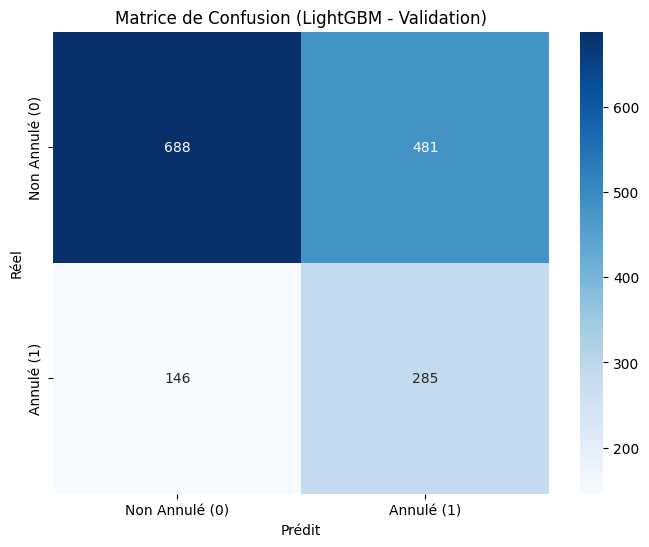

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Désactiver les logs verbeux d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# Split train/validation pour Optuna (sans train_test_split sur l'ensemble X global)
# Cela crée un jeu d'entraînement et un jeu de validation à partir de l'ensemble d'entraînement original (X, y)
# IMPORTANT: Les variables X et y ici sont l'ensemble d'entraînement global.
# Les variables X_test (global) et df_reservations_test_processed (global) sont l'ensemble de test EXTERN d'origine.
# Nous utiliserons X_train_optuna et X_val_optuna pour l'optimisation Optuna.
# ============================================================
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train_optuna, X_val_optuna = X.iloc[:split_index], X.iloc[split_index:]
y_train_optuna, y_val_optuna = y.iloc[:split_index], y.iloc[split_index:]

print(f"Taille X_train_optuna: {X_train_optuna.shape}, X_val_optuna: {X_val_optuna.shape}")
print(f"Taille y_train_optuna: {y_train_optuna.shape}, y_val_optuna: {y_val_optuna.shape}")

def objective(trial):
    """
    Fonction objectif pour Optuna afin d'optimiser LightGBM.
    """
    # 1. Définir l'espace de recherche des hyperparamètres
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,

        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),

        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        'class_weight': 'balanced'
    }

    # 2. Instancier le modèle LightGBM
    model = LGBMClassifier(**params)

    # 3. Évaluer le modèle en utilisant la validation croisée stratifiée
    # (uniquement sur X_train_optuna / y_train_optuna pour ne pas toucher au test ni au validation_optuna)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_train_optuna, y_train_optuna, cv=kf, scoring='roc_auc', n_jobs=-1)

    # Retourner la moyenne des scores pour Optuna à maximiser
    return np.mean(scores)

# 4. Créer et exécuter l'étude Optuna
print("Début de l'optimisation des hyperparamètres avec Optuna...")
study = optuna.create_study(direction='maximize', study_name='LightGBM Optimization')
study.optimize(objective, n_trials=50) # Exécuter 50 essais

print("\nOptimisation terminée.")
print(f"Meilleur essai (trial):\n  Valeur (AUC-ROC moyenne): {study.best_value:.4f}\n  Hyperparamètres: {study.best_params}")

# 5. Entraîner le modèle final avec les meilleurs hyperparamètres
best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1
best_params['class_weight'] = 'balanced'

final_lgb_model = LGBMClassifier(**best_params)
final_lgb_model.fit(X_train_optuna, y_train_optuna)

print("\nModèle final LightGBM entraîné sur l'ensemble d'entraînement Optuna avec les meilleurs hyperparamètres.")

# 6. Générer les prédictions sur l'ensemble de VALIDATION (X_val_optuna) pour les métriques
y_pred_val_optuna = final_lgb_model.predict(X_val_optuna)
y_proba_val_optuna = final_lgb_model.predict_proba(X_val_optuna)[:, 1]

# ============================================================
# Affichage des métriques sur l'ensemble de VALIDATION
# ============================================================
lgb_accuracy = accuracy_score(y_val_optuna, y_pred_val_optuna)
lgb_precision = precision_score(y_val_optuna, y_pred_val_optuna)
lgb_recall = recall_score(y_val_optuna, y_pred_val_optuna)
lgb_f1 = f1_score(y_val_optuna, y_pred_val_optuna)
lgb_roc_auc = roc_auc_score(y_val_optuna, y_proba_val_optuna)

print(f"LightGBM Accuracy (Validation): {lgb_accuracy:.4f}")
print(f"LightGBM Precision (Validation): {lgb_precision:.4f}")
print(f"LightGBM Recall (Validation): {lgb_recall:.4f}")
print(f"LightGBM F1-Score (Validation): {lgb_f1:.4f}")
print(f"LightGBM AUC-ROC (Validation): {lgb_roc_auc:.4f}")

# Afficher la matrice de confusion pour LightGBM sur l'ensemble de validation
lgb_cm = confusion_matrix(y_val_optuna, y_pred_val_optuna)
plt.figure(figsize=(8, 6))
sns.heatmap(lgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Annulé (0)', 'Annulé (1)'], yticklabels=['Non Annulé (0)', 'Annulé (1)'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (LightGBM - Validation)')
plt.show()

### Génération des Prédictions pour `X_test` et Exportation vers CSV

Nous allons maintenant utiliser le `final_logistic_model` pour prédire la probabilité d'annulation (`probabilite_annulation`) et la classe d'annulation binaire (`reservation_annulee`) pour l'ensemble `X_test`. Les résultats seront compilés avec les `reservation_id` correspondants et sauvegardés dans un fichier CSV.

In [ ]:
import os


# Re-créer X_test à partir de df_test_encoded pour s'assurer qu'il s'agit du bon ensemble de test externe (2000 lignes)
# `columns_to_drop_from_X` et `numerical_cols_to_scale` sont des variables globales définies précédemment.
X_test_external = df_test_encoded.drop(columns=columns_to_drop_from_X)

# Appliquer la même mise à l'échelle que les données d'entraînement, en utilisant le scaler déjà ajusté
X_test_external[numerical_cols_to_scale] = scaler.transform(X_test_external[numerical_cols_to_scale])

# 1. Obtenir les prédictions et les probabilités pour X_test (l'ensemble de test EXTERNE)
y_proba_external_test = final_logistic_model.predict_proba(X_test_external)[:, 1]
y_pred_external_test = final_logistic_model.predict(X_test_external)

# 2. Récupérer les reservation_id correspondants pour X_test (l'ensemble de test EXTERNE)
reservation_ids_external_test = df_reservations_test_processed['reservation_id']

# 3. Créer un DataFrame avec les résultats
predictions_df = pd.DataFrame({
    'reservation_id': reservation_ids_external_test,
    'probabilite_annulation': y_proba_external_test,
    'reservation_annulee': y_pred_external_test
})

# 4. Afficher les 5 premières lignes du DataFrame de prédictions
print("Aperçu des prédictions pour le jeu de test externe :")
display(predictions_df.head())
folder_path = os.getcwd()
# 5. Sauvegarder les résultats dans un fichier CSV
output_csv_path = os.path.join(folder_path, 'predictions_logistic_regression.csv')
predictions_df.to_csv(output_csv_path, index=False)

print(f"Prédictions sauvegardées dans : {output_csv_path}")

SyntaxError: invalid syntax (2691804734.py, line 28)

### Évaluation du Modèle Final avec Validation Croisée (F1-score) sur l'ensemble d'entraînement Complet

Comme demandé, nous allons évaluer le `final_logistic_model` sur l'ensemble de données d'entraînement complet (`X`, `y`) en utilisant une validation croisée stratifiée pour obtenir une estimation robuste du F1-score, sans utiliser un `train_test_split` unique.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Définir le scorer F1
f1_scorer = make_scorer(f1_score)

# Initialiser StratifiedKFold pour la validation croisée sur l'ensemble X, y complet
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculer le F1-score en utilisant la validation croisée
f1_scores_full_train = cross_val_score(final_logistic_model, X, y, cv=kf, scoring=f1_scorer, n_jobs=-1)

print(f"F1-scores pour chaque fold sur l'ensemble d'entraînement complet : {f1_scores_full_train}")
print(f"F1-score moyen (Validation Croisée sur l'entraînement complet) : {np.mean(f1_scores_full_train):.4f}")
print(f"Écart-type du F1-score (Validation Croisée sur l'entraînement complet) : {np.std(f1_scores_full_train):.4f}")